# Thí Nghiệm So Sánh Kiến Trúc VAE — Hidden Dimensions

**Dự án:** NIDS-VAE — Phát hiện xâm nhập mạng bằng Variational Autoencoder  
**Dataset:** CICIDS2017  
**Ngày:** 2026-05-31  

---

Notebook này thực hiện nghiên cứu có hệ thống nhằm trả lời câu hỏi:  
> **Tại sao đề tài lựa chọn kiến trúc 66 → 128 → 64 → latent 16 thay vì các cấu hình khác?**

## Section 1 — Giới Thiệu Thí Nghiệm

### 1.1 Mục tiêu nghiên cứu

Tìm kiến trúc hidden layers tối ưu cho VAE phát hiện bất thường trên CICIDS2017, cụ thể:
- Đánh giá ảnh hưởng của kích thước hidden dims đến **khả năng tái tạo** và **hiệu năng phát hiện**.
- So sánh **tốc độ hội tụ**, **validation loss**, và các **metrics phân loại** (F1, Recall, ROC-AUC).
- Lý giải lựa chọn `[128, 64]` trong pipeline triển khai.

### 1.2 Giả thuyết nghiên cứu

| Giả thuyết | Nội dung |
|---|---|
| H1 | Kiến trúc quá nhỏ (`[64, 32]`) không đủ khả năng biểu diễn 66 đặc trưng → reconstruction error cao |
| H2 | Kiến trúc quá lớn (`[256, 128]`) dễ overfit trên normal traffic → khó phân biệt anomaly |
| H3 | Kiến trúc `[128, 64]` cân bằng giữa biểu diễn và tổng quát hóa → F1 và ROC-AUC tốt nhất |
| H4 | Kiến trúc không cân đối (`[128, 32]`) tạo bottleneck đột ngột → reconstruction kém |

### 1.3 Các cấu hình được so sánh

| Config | Hidden Dims | Mô tả | Tham số ước tính |
|---|---|---|---|
| **A** | `[64, 32]` | Kiến trúc nhỏ gọn | ~11K params |
| **B** | `[128, 64]` | **Kiến trúc đã chọn** ✓ | ~37K params |
| **C** | `[256, 128]` | Kiến trúc lớn | ~128K params |
| **D** | `[128, 32]` | Kiến trúc không đối xứng | ~25K params |

**Tất cả cấu hình giữ nguyên:** `latent_dim=16`, `lr=1e-3`, `batch_size=1024`, `seed=42`

## Section 2 — Cài Đặt Môi Trường

Import thư viện, cấu hình đường dẫn, và thiết lập chế độ thí nghiệm.

In [11]:
# ============================================================
# Cấu hình chế độ thí nghiệm
# QUICK_EXPERIMENT=True : chạy ít epoch để kiểm tra nhanh
# QUICK_EXPERIMENT=False: chạy đầy đủ để có kết quả báo cáo
# ============================================================
QUICK_EXPERIMENT = False   # Đặt True để chạy nhanh (~2 phút)

if QUICK_EXPERIMENT:
    MAX_EPOCHS  = 15
    PATIENCE    = 5
    BATCH_SIZE  = 2048
    print("[QUICK MODE] Chạy nhanh: max_epochs=15, patience=5")
else:
    MAX_EPOCHS  = 100
    PATIENCE    = 10
    BATCH_SIZE  = 1024
    print("[FULL MODE] Chạy đầy đủ: max_epochs=100, patience=10")

[FULL MODE] Chạy đầy đủ: max_epochs=100, patience=10


In [12]:
# ============================================================
# Import thư viện chuẩn và thiết lập đường dẫn project
# ============================================================
import sys
import time
import json
import random
import warnings
from pathlib import Path
from copy import deepcopy

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    confusion_matrix,
)

warnings.filterwarnings("ignore")

# ── Thiết lập PROJECT_ROOT để import module nội bộ ────────────────────────
# Notebook nằm trong notebooks/ → PROJECT_ROOT là thư mục cha
PROJECT_ROOT = Path("__file__").resolve().parent.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Xử lý trường hợp chạy từ thư mục notebooks/ hoặc project root
import os
_cwd = Path(os.getcwd())
if _cwd.name == "notebooks":
    PROJECT_ROOT = _cwd.parent
elif (_cwd / "notebooks").exists():
    PROJECT_ROOT = _cwd
else:
    PROJECT_ROOT = _cwd.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"PROJECT_ROOT : {PROJECT_ROOT}")
print(f"Python       : {sys.version.split()[0]}")
print(f"PyTorch      : {torch.__version__}")
print(f"CUDA         : {torch.cuda.is_available()}")

PROJECT_ROOT : d:\nids-vae-project
Python       : 3.12.10
PyTorch      : 2.12.0+cpu
CUDA         : False


In [13]:
# ============================================================
# Tái sử dụng kiến trúc VAE từ module backend hiện có
# ============================================================
from backend.app.models.vae import VAE, vae_loss

print("✓ Import VAE thành công từ backend.app.models.vae")
print(f"  VAE class: {VAE}")

✓ Import VAE thành công từ backend.app.models.vae
  VAE class: <class 'backend.app.models.vae.VAE'>


In [14]:
# ============================================================
# Hằng số thí nghiệm — cố định để đảm bảo so sánh công bằng
# ============================================================

# Tham số kiến trúc cố định cho tất cả cấu hình
INPUT_DIM       = 66        # Số feature CICIDS2017 sau khi xử lý
LATENT_DIM      = 16        # Số chiều không gian tiềm ẩn (giữ nguyên)
LEARNING_RATE   = 1e-3      # Learning rate Adam (theo train.py gốc)
WEIGHT_DECAY    = 1e-5      # L2 regularization (theo train.py gốc)
GRAD_CLIP_NORM  = 5.0       # Gradient clipping norm (theo train.py gốc)
RANDOM_SEED     = 42        # Seed cố định để reproducible

# KL Annealing: tránh posterior collapse
BETA_START          = 0.0
BETA_END            = 1.0
BETA_WARMUP_EPOCHS  = 30

# Ngưỡng phát hiện anomaly: percentile 99 trên validation errors (BENIGN only)
THRESHOLD_PERCENTILE = 99.0

# Đường dẫn dữ liệu đã được xử lý bởi scripts/clean_data.py
DATA_TRAIN_DIR = PROJECT_ROOT / "data" / "train"
DATA_VAL_DIR   = PROJECT_ROOT / "data" / "validation"
DATA_TEST_DIR  = PROJECT_ROOT / "data" / "test"

# 4 cấu hình kiến trúc cần so sánh
CONFIGS = [
    {"name": "A", "hidden_dims": [64, 32],   "label": "Config A: [64, 32]"},
    {"name": "B", "hidden_dims": [128, 64],  "label": "Config B: [128, 64] ★"},  # Đã chọn
    {"name": "C", "hidden_dims": [256, 128], "label": "Config C: [256, 128]"},
    {"name": "D", "hidden_dims": [128, 32],  "label": "Config D: [128, 32]"},
]

# Device: ưu tiên CUDA, fallback về CPU
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device sử dụng: {DEVICE}")
print(f"Batch size     : {BATCH_SIZE}")
print(f"Max epochs     : {MAX_EPOCHS}")
print(f"Patience       : {PATIENCE}")
print(f"\nCác cấu hình cần so sánh:")
for cfg in CONFIGS:
    marker = " ← Đã triển khai" if cfg["name"] == "B" else ""
    print(f"  Config {cfg['name']}: hidden_dims={cfg['hidden_dims']}{marker}")

Device sử dụng: cpu
Batch size     : 1024
Max epochs     : 100
Patience       : 10

Các cấu hình cần so sánh:
  Config A: hidden_dims=[64, 32]
  Config B: hidden_dims=[128, 64] ← Đã triển khai
  Config C: hidden_dims=[256, 128]
  Config D: hidden_dims=[128, 32]


## Section 3 — Load Dữ Liệu

Load X_train, X_val, X_test, y_val, y_test từ các file `.npy` được tạo bởi `scripts/clean_data.py`.  
Hiển thị shape và phân bố nhãn BENIGN/ATTACK.

In [15]:
# ============================================================
# Load dữ liệu từ file .npy đã xử lý trước
# Dữ liệu đã được: chuẩn hóa, loại NaN/Inf, và scaled
# ============================================================

def load_split_data(project_root: Path) -> dict:
    """Tải tất cả split data (train/val/test) và kiểm tra tính hợp lệ."""
    train_dir = project_root / "data" / "train"
    val_dir   = project_root / "data" / "validation"
    test_dir  = project_root / "data" / "test"

    # Kiểm tra file tồn tại trước khi load
    required = [
        train_dir / "X_train.npy",
        val_dir   / "X_val.npy",
        val_dir   / "y_val.npy",
        test_dir  / "X_test.npy",
        test_dir  / "y_test.npy",
    ]
    for p in required:
        if not p.exists():
            raise FileNotFoundError(
                f"Thiếu file: {p}\n"
                "Hãy chạy: python scripts/clean_data.py"
            )

    data = {
        "X_train": np.load(train_dir / "X_train.npy").astype(np.float32),
        "X_val"  : np.load(val_dir   / "X_val.npy").astype(np.float32),
        "y_val"  : np.load(val_dir   / "y_val.npy"),
        "X_test" : np.load(test_dir  / "X_test.npy").astype(np.float32),
        "y_test" : np.load(test_dir  / "y_test.npy"),
    }

    # Kiểm tra không có NaN/Inf — bắt buộc theo quy tắc dự án
    for key in ["X_train", "X_val", "X_test"]:
        arr = data[key]
        assert not np.isnan(arr).any(), f"{key} chứa NaN!"
        assert not np.isinf(arr).any(), f"{key} chứa Inf!"

    return data


# Load dữ liệu
data = load_split_data(PROJECT_ROOT)
X_train = data["X_train"]
X_val   = data["X_val"]
y_val   = data["y_val"]
X_test  = data["X_test"]
y_test  = data["y_test"]

print("=== Shape dữ liệu ===")
print(f"X_train : {X_train.shape}  (chỉ BENIGN — dùng để huấn luyện)")
print(f"X_val   : {X_val.shape}")
print(f"y_val   : {y_val.shape}    (0=BENIGN, 1=ATTACK)")
print(f"X_test  : {X_test.shape}")
print(f"y_test  : {y_test.shape}")

=== Shape dữ liệu ===
X_train : (402229, 66)  (chỉ BENIGN — dùng để huấn luyện)
X_val   : (100558, 66)
y_val   : (100558,)    (0=BENIGN, 1=ATTACK)
X_test  : (2019575, 66)
y_test  : (2019575,)


In [16]:
# ============================================================
# Hiển thị phân bố nhãn trong tập validation và test
# ============================================================

def print_label_distribution(y: np.ndarray, split_name: str) -> None:
    """In phân bố nhãn BENIGN/ATTACK và tỉ lệ phần trăm."""
    n_total  = len(y)
    n_normal = int((y == 0).sum())
    n_attack = int((y == 1).sum())
    print(f"  {split_name}: {n_total:>10,} mẫu | "
          f"BENIGN={n_normal:>8,} ({100*n_normal/n_total:.1f}%) | "
          f"ATTACK={n_attack:>8,} ({100*n_attack/n_total:.1f}%)")


print("=== Phân bố nhãn ===")
# Train chỉ có BENIGN — VAE học phân phối normal traffic
print(f"  X_train : {len(X_train):>10,} mẫu | BENIGN=100% (chỉ train trên normal traffic)")
print_label_distribution(y_val,  "X_val  ")
print_label_distribution(y_test, "X_test ")

# Số lượng BENIGN trong val (dùng để tính threshold)
n_val_benign = int((y_val == 0).sum())
print(f"\n→ Threshold sẽ được tính từ {n_val_benign:,} mẫu BENIGN trong validation set")
print(f"→ Phương pháp: percentile {THRESHOLD_PERCENTILE}% của validation errors")

=== Phân bố nhãn ===
  X_train :    402,229 mẫu | BENIGN=100% (chỉ train trên normal traffic)
  X_val  :    100,558 mẫu | BENIGN= 100,558 (100.0%) | ATTACK=       0 (0.0%)
  X_test :  2,019,575 mẫu | BENIGN=1,593,697 (78.9%) | ATTACK= 425,878 (21.1%)

→ Threshold sẽ được tính từ 100,558 mẫu BENIGN trong validation set
→ Phương pháp: percentile 99.0% của validation errors


## Section 4 — Xây Dựng VAE Linh Hoạt

Tái sử dụng lớp `VAE` từ `backend/app/models/vae.py` — đây là nguồn duy nhất cho kiến trúc VAE trong dự án.  
Tham số `hidden_dims` có thể truyền bất kỳ danh sách kích thước nào.

In [17]:
# ============================================================
# Kiểm tra VAE linh hoạt với từng cấu hình hidden_dims
# Xác nhận kiến trúc và số tham số trước khi training
# ============================================================

def count_parameters(model: nn.Module) -> int:
    """Đếm tổng số tham số có thể học của model."""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def describe_vae_architecture(hidden_dims: list, input_dim: int = 66, latent_dim: int = 16) -> str:
    """Tạo chuỗi mô tả kiến trúc encoder: input → hidden → latent."""
    layers = [str(input_dim)] + [str(h) for h in hidden_dims] + [f"z={latent_dim}"]
    return " → ".join(layers)


print("=== Kiểm tra kiến trúc các cấu hình ===")
print(f"{'Config':<10} {'Hidden Dims':<15} {'Kiến trúc Encoder':<35} {'#Params':>10}")
print("-" * 75)

for cfg in CONFIGS:
    # Khởi tạo VAE với hidden_dims tùy chỉnh
    model_test = VAE(
        input_dim   = INPUT_DIM,
        latent_dim  = LATENT_DIM,
        hidden_dims = cfg["hidden_dims"],
    )
    n_params   = count_parameters(model_test)
    arch_str   = describe_vae_architecture(cfg["hidden_dims"])
    marker     = " ← Đã triển khai" if cfg["name"] == "B" else ""
    print(f"Config {cfg['name']:<4} {str(cfg['hidden_dims']):<15} {arch_str:<35} {n_params:>10,}{marker}")
    del model_test

print("\n✓ Tất cả cấu hình khởi tạo thành công.")
print("✓ VAE class tái sử dụng từ backend.app.models.vae — không tạo mới.")

=== Kiểm tra kiến trúc các cấu hình ===
Config     Hidden Dims     Kiến trúc Encoder                      #Params
---------------------------------------------------------------------------
Config A    [64, 32]        66 → 64 → 32 → z=16                     14,370
Config B    [128, 64]       66 → 128 → 64 → z=16                    36,834 ← Đã triển khai
Config C    [256, 128]      66 → 256 → 128 → z=16                  106,338
Config D    [128, 32]       66 → 128 → 32 → z=16                    27,042

✓ Tất cả cấu hình khởi tạo thành công.
✓ VAE class tái sử dụng từ backend.app.models.vae — không tạo mới.


## Section 5 — Huấn Luyện Từng Cấu Hình

Huấn luyện lần lượt 4 cấu hình với cùng hyperparameters.  
Lưu kết quả từng cấu hình để so sánh ở section tiếp theo.

In [18]:
# ============================================================
# Các hàm tiện ích cho training loop
# Tái sử dụng logic từ scripts/train.py — không sửa file gốc
# ============================================================

def set_seed(seed: int) -> None:
    """Cố định random seed để kết quả reproducible trên tất cả thư viện."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark     = False


def get_beta(epoch: int, beta_start: float, beta_end: float, warmup: int) -> float:
    """Tính beta cho KL annealing tuyến tính theo epoch."""
    if warmup <= 0:
        return beta_end
    progress = min(float(epoch) / float(warmup), 1.0)
    return beta_start + (beta_end - beta_start) * progress


def make_dataloaders(X_train: np.ndarray, X_val: np.ndarray, batch_size: int):
    """Tạo DataLoader cho train và val. num_workers=0 để tương thích Windows."""
    train_tensor = torch.from_numpy(X_train)
    val_tensor   = torch.from_numpy(X_val)

    train_loader = DataLoader(
        TensorDataset(train_tensor),
        batch_size  = batch_size,
        shuffle     = True,
        num_workers = 0,   # Windows: không dùng worker phụ
        pin_memory  = torch.cuda.is_available(),
    )
    val_loader = DataLoader(
        TensorDataset(val_tensor),
        batch_size  = batch_size,
        shuffle     = False,
        num_workers = 0,
        pin_memory  = torch.cuda.is_available(),
    )
    return train_loader, val_loader


def train_one_epoch(
    model: VAE,
    loader: DataLoader,
    optimizer: torch.optim.Optimizer,
    device: torch.device,
    beta: float,
) -> float:
    """Huấn luyện một epoch, trả về average validation loss."""
    model.train()
    total = 0.0
    n     = 0
    for (x,) in loader:
        x = x.to(device, non_blocking=True)
        optimizer.zero_grad()
        x_hat, mu, logvar = model(x)
        loss, _, _ = vae_loss(x, x_hat, mu, logvar, beta=beta)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
        optimizer.step()
        total += loss.item()
        n     += 1
    return total / n


@torch.no_grad()
def evaluate_loader(
    model: VAE,
    loader: DataLoader,
    device: torch.device,
    beta: float,
) -> float:
    """Tính validation loss — không cập nhật gradient."""
    model.eval()
    total = 0.0
    n     = 0
    for (x,) in loader:
        x = x.to(device, non_blocking=True)
        x_hat, mu, logvar = model(x)
        loss, _, _ = vae_loss(x, x_hat, mu, logvar, beta=beta)
        total += loss.item()
        n     += 1
    return total / n


@torch.no_grad()
def compute_reconstruction_errors(
    model: VAE,
    X: np.ndarray,
    device: torch.device,
    batch_size: int = 4096,
) -> np.ndarray:
    """
    Tính reconstruction error (MSE per sample) cho toàn bộ tập X.
    Công thức: error_i = mean((x_i - x_hat_i)^2)  — theo VAE.reconstruction_error()
    """
    model.eval()
    tensor  = torch.from_numpy(X.astype(np.float32))
    dataset = TensorDataset(tensor)
    loader  = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=0)

    errors_list = []
    for (x,) in loader:
        x     = x.to(device)
        x_hat, mu, _ = model(x)
        err   = VAE.reconstruction_error(x, x_hat)   # Dùng method chuẩn của class
        errors_list.append(err.cpu().numpy())

    return np.concatenate(errors_list)


print("✓ Đã định nghĩa các hàm huấn luyện và đánh giá.")

✓ Đã định nghĩa các hàm huấn luyện và đánh giá.


In [ ]:
# ⚠️ ============================================================
# [ARCHIVED — BUGGY RESULT v1 — KHÔNG DÙNG CHO BÁO CÁO]
# BUG: Early stopping kích hoạt trong giai đoạn KL warmup (epoch 1–30)
#      val_loss tăng tự nhiên do beta tăng → best_epoch = 1 (artefact)
# FIX: Dùng train_config_v2() trong Section 12 thay thế
# ⚠️ ============================================================
if False:   # ← Ngăn tái thực thi; giữ code để tham khảo
    # ============================================================
    # Hàm training hoàn chỉnh cho một cấu hình VAE
    # Trả về dict kết quả để so sánh sau
    # ============================================================

    def train_config(
        config: dict,
        X_train: np.ndarray,
        X_val: np.ndarray,
        device: torch.device,
        max_epochs: int,
        patience: int,
        batch_size: int,
    ) -> dict:
        name        = config["name"]
        hidden_dims = config["hidden_dims"]
        set_seed(RANDOM_SEED)
        model = VAE(input_dim=INPUT_DIM, latent_dim=LATENT_DIM,
                    hidden_dims=hidden_dims).to(device)
        n_params  = count_parameters(model)
        optimizer = torch.optim.Adam(model.parameters(),
                                     lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
        train_loader, val_loader = make_dataloaders(X_train, X_val, batch_size)

        best_val_loss, best_model_state = float("inf"), None
        best_epoch, epochs_no_improve   = 0, 0
        val_history = []

        for epoch in range(1, max_epochs + 1):
            beta       = get_beta(epoch, BETA_START, BETA_END, BETA_WARMUP_EPOCHS)
            train_loss = train_one_epoch(model, train_loader, optimizer, device, beta)
            val_loss   = evaluate_loader(model, val_loader, device, beta)
            val_history.append(val_loss)

            # BUG: không có warmup guard → best_epoch=1 (beta gần 0 tại epoch 1)
            if val_loss < best_val_loss:
                best_val_loss    = val_loss
                best_model_state = deepcopy(model.state_dict())
                best_epoch       = epoch
                epochs_no_improve = 0
            else:
                epochs_no_improve += 1
                if epochs_no_improve >= patience:
                    break

        return {
            "config_name": name, "hidden_dims": hidden_dims, "n_params": n_params,
            "best_epoch": best_epoch, "best_val_loss": best_val_loss,
            "val_history": val_history, "model_state_dict": best_model_state,
            "train_time_sec": 0.0,
        }

print("⚠️  [ARCHIVED] train_config() v1 đã bị vô hiệu hoá. Dùng train_config_v2() ở Section 12.")


✓ Đã định nghĩa hàm train_config.


In [ ]:
# ⚠️ [ARCHIVED — BUGGY RESULT v1 — KHÔNG DÙNG CHO BÁO CÁO]
# Vòng lặp training v1 dùng train_config() có lỗi early stopping trong warmup.
# Kết quả: best_epoch=1 cho tất cả 4 config → không đáng tin cậy.
# Dùng ô training_results_v2 trong Section 12 thay thế.
if False:
    training_results = []
    total_start = time.time()
    for cfg in CONFIGS:
        result = train_config(
            config=cfg, X_train=X_train, X_val=X_val, device=DEVICE,
            max_epochs=MAX_EPOCHS, patience=PATIENCE, batch_size=BATCH_SIZE,
        )
        training_results.append(result)

print("⚠️  [ARCHIVED] Vòng lặp training v1 đã bị vô hiệu hoá. Xem Section 12.")


Bắt đầu huấn luyện 4 cấu hình...
Device: cpu | Batch: 1024 | Max epochs: 100

Training Config A: hidden_dims=[64, 32]
  #Params: 14,370
  Epoch   1/100 | train=0.7574 | val=0.4618 | beta=0.03 | 6s
  Epoch   5/100 | train=0.6304 | val=0.5443 | beta=0.17 | 43s
  Epoch  10/100 | train=0.6872 | val=0.6245 | beta=0.33 | 93s
  → Early stopping tại epoch 11 (best=1, val_loss=0.461791)
  Hoàn thành: best_epoch=1, best_val_loss=0.461791, thời gian=102.6s

Training Config B: hidden_dims=[128, 64]
  #Params: 36,834
  Epoch   1/100 | train=1196.3209 | val=0.3786 | beta=0.03 | 11s
  Epoch   5/100 | train=0.5713 | val=0.4834 | beta=0.17 | 53s
  Epoch  10/100 | train=0.6840 | val=0.5960 | beta=0.33 | 106s
  → Early stopping tại epoch 11 (best=1, val_loss=0.378644)
  Hoàn thành: best_epoch=1, best_val_loss=0.378644, thời gian=116.2s

Training Config C: hidden_dims=[256, 128]
  #Params: 106,338
  Epoch   1/100 | train=0.7799 | val=0.3155 | beta=0.03 | 12s
  Epoch   5/100 | train=0.5596 | val=0.4666 | b

## Section 6 — Đánh Giá Từng Cấu Hình

Tính reconstruction error trên tập validation (chỉ BENIGN) và test, sau đó tính đầy đủ metrics phân loại.

In [21]:
# ============================================================
# Hàm đánh giá một cấu hình: tính threshold và metrics
# Quy trình nhất quán với scripts/evaluate.py gốc
# ============================================================

def evaluate_config(
    result: dict,
    X_val: np.ndarray,
    y_val: np.ndarray,
    X_test: np.ndarray,
    y_test: np.ndarray,
    device: torch.device,
    threshold_percentile: float = 99.0,
) -> dict:
    """
    Đánh giá một cấu hình VAE đã huấn luyện.

    Quy trình:
      1. Tải lại model với best_state_dict
      2. Tính reconstruction error trên val BENIGN → chọn threshold
      3. Tính reconstruction error trên test → phân loại anomaly
      4. Tính accuracy, precision, recall, F1, ROC-AUC, FPR

    Thresholds được tính chỉ từ BENIGN validation samples
    → đồng nhất với scripts/evaluate.py gốc.
    """
    hidden_dims = result["hidden_dims"]

    # Tái tạo VAE và load best weights
    model = VAE(
        input_dim   = INPUT_DIM,
        latent_dim  = LATENT_DIM,
        hidden_dims = hidden_dims,
    ).to(device)
    model.load_state_dict(result["model_state_dict"])
    model.eval()

    # Tính reconstruction errors trên toàn bộ val và test
    val_errors  = compute_reconstruction_errors(model, X_val,  device)
    test_errors = compute_reconstruction_errors(model, X_test, device)

    # Chọn threshold: percentile của errors trên BENIGN validation
    val_benign_errors = val_errors[y_val == 0]
    threshold = float(np.percentile(val_benign_errors, threshold_percentile))

    # Phân loại: error > threshold → anomaly (1), ngược lại → normal (0)
    y_pred = (test_errors > threshold).astype(int)

    # Tính các metrics phân loại
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred, zero_division=0)
    f1   = f1_score(y_test, y_pred, zero_division=0)

    # ROC-AUC dùng continuous scores (reconstruction error)
    try:
        roc_auc = roc_auc_score(y_test, test_errors)
    except Exception:
        roc_auc = float("nan")

    # Confusion matrix để tính FPR (False Positive Rate)
    cm  = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0

    print(f"  Config {result['config_name']}: threshold={threshold:.4f} | "
          f"F1={f1:.4f} | Recall={rec:.4f} | ROC-AUC={roc_auc:.4f} | FPR={fpr:.4f}")

    return {
        **result,
        "threshold"     : threshold,
        "val_errors"    : val_errors,
        "test_errors"   : test_errors,
        "accuracy"      : acc,
        "precision"     : prec,
        "recall"        : rec,
        "f1"            : f1,
        "roc_auc"       : roc_auc,
        "fpr"           : fpr,
        "confusion_matrix": cm.tolist(),
        "tp": int(tp), "tn": int(tn), "fp": int(fp), "fn": int(fn),
    }


print("✓ Đã định nghĩa hàm evaluate_config.")

✓ Đã định nghĩa hàm evaluate_config.


In [ ]:
# ⚠️ [ARCHIVED — BUGGY RESULT v1 — KHÔNG DÙNG CHO BÁO CÁO]
# evaluation_results v1 được tính từ model chưa hội tụ (best_epoch=1).
# Dùng evaluation_results_v2 trong Section 12 thay thế.
if False:
    evaluation_results = []
    for result in training_results:
        eval_result = evaluate_config(
            result=result, X_val=X_val, y_val=y_val,
            X_test=X_test, y_test=y_test, device=DEVICE,
            threshold_percentile=THRESHOLD_PERCENTILE,
        )
        evaluation_results.append(eval_result)

print("⚠️  [ARCHIVED] evaluation_results v1 đã bị vô hiệu hoá. Xem Section 12.")


Đang tính reconstruction errors và metrics...
  Config A: threshold=2.9621 | F1=0.6705 | Recall=0.5538 | ROC-AUC=0.8581 | FPR=0.0262
  Config B: threshold=1.8237 | F1=0.6546 | Recall=0.5340 | ROC-AUC=0.8687 | FPR=0.0261
  Config C: threshold=1.2174 | F1=0.6640 | Recall=0.5564 | ROC-AUC=0.8997 | FPR=0.0320
  Config D: threshold=2.2206 | F1=0.6420 | Recall=0.5177 | ROC-AUC=0.8688 | FPR=0.0253

✓ Đánh giá hoàn thành.


## ~~Section 7 — Bảng So Sánh Tổng Hợp~~ `[ARCHIVED — BUGGY RESULT v1]`

> ⚠️ **Phần này bị vô hiệu hoá.** Kết quả dựa trên `training_results` v1 với `best_epoch = 1` (artefact của KL warmup).  
> Xem **Section 13** để xem bảng so sánh chính thức từ `evaluation_results_v2`.

In [ ]:
# ⚠️ [ARCHIVED — BUGGY RESULT v1 — KHÔNG DÙNG CHO BÁO CÁO]
# df_results được tạo từ evaluation_results v1 (best_epoch=1, model chưa hội tụ).
# Dùng df_v2 trong Section 13 thay thế.
if False:
    rows = []
    for r in evaluation_results:
        rows.append({
            "Config": r["config_name"], "Hidden Dims": str(r["hidden_dims"]),
            "#Params": r["n_params"], "Best Epoch": r["best_epoch"],
            "Best Val Loss": round(r["best_val_loss"], 6),
            "F1": round(r["f1"], 4), "Recall": round(r["recall"], 4),
            "ROC-AUC": round(r["roc_auc"], 4), "FPR": round(r["fpr"], 4),
            "Train Time (s)": round(r["train_time_sec"], 1),
        })
    df_results = pd.DataFrame(rows)

print("⚠️  [ARCHIVED] df_results v1 đã bị vô hiệu hoá. Dùng df_v2 ở Section 13.")


BẢNG SO SÁNH KIẾN TRÚC VAE — CICIDS2017
Config Hidden Dims  #Params  Best Epoch  Best Val Loss  Threshold  Accuracy  Precision  Recall     F1  ROC-AUC    FPR  Train Time (s)         Ghi chú
     A    [64, 32]    14370           1         0.4618     2.9621    0.8852     0.8495  0.5538 0.6705   0.8581 0.0262        102.6000                
     B   [128, 64]    36834           1         0.3786     1.8237    0.8812     0.8455  0.5340 0.6546   0.8687 0.0261        116.2000 ★ Đã triển khai
     C  [256, 128]   106338           1         0.3155     1.2174    0.8812     0.8230  0.5564 0.6640   0.8997 0.0320        154.7000                
     D   [128, 32]    27042           1         0.3999     2.2206    0.8783     0.8451  0.5177 0.6420   0.8688 0.0253        105.1000                

Threshold percentile: 99.0% trên BENIGN validation errors


In [ ]:
# ⚠️ [ARCHIVED — BUGGY RESULT v1 — KHÔNG DÙNG CHO BÁO CÁO]
# Bảng styled này hiển thị df_results v1 (best_epoch=1 cho tất cả config).
# Dùng bảng styled v2 trong Section 13 thay thế.

# Các hàm helper vẫn được định nghĩa để tái sử dụng trong Section 13
def highlight_best(s, props="background-color: #cfe2ff; font-weight: bold; color: black"):
    """Highlight giá trị tốt nhất (cao nhất) trong mỗi cột metric."""
    return np.where(s == s.max(), props, "")

def highlight_best_min(s, props="background-color: #cfe2ff; font-weight: bold; color: black"):
    """Highlight giá trị tốt nhất (thấp nhất) trong cột FPR và Val Loss."""
    return np.where(s == s.min(), props, "")

def highlight_selected(row, props="background-color: #fff3cd; font-weight: bold; color: black"):
    """Highlight toàn bộ hàng config đã được chọn triển khai (Config B)."""
    if row["Config"] == "B":
        return [props] * len(row)
    return [""] * len(row)

print("✓ Đã định nghĩa các hàm highlight (tái sử dụng ở Section 13).")
print("⚠️  [ARCHIVED] Bảng styled v1 đã bị vô hiệu hoá. Xem Section 13.")


,Config,Hidden Dims,Best Epoch,Best Val Loss,Accuracy,Precision,Recall,F1,ROC-AUC,FPR,Train Time (s),Ghi chú
0,A,"[64, 32]",1,0.461791,0.8852,0.8495,0.5538,0.6705,0.8581,0.0262,102.6,
1,B,"[128, 64]",1,0.378644,0.8812,0.8455,0.5340,0.6546,0.8687,0.0261,116.2,★ Đã triển khai
2,C,"[256, 128]",1,0.315467,0.8812,0.8230,0.5564,0.6640,0.8997,0.0320,154.7,
3,D,"[128, 32]",1,0.399942,0.8783,0.8451,0.5177,0.6420,0.8688,0.0253,105.1,


## ~~Section 8 — Visualization~~ `[ARCHIVED — BUGGY RESULT v1]`

> ⚠️ **Phần này bị vô hiệu hoá.** Tất cả biểu đồ dưới đây được vẽ từ `evaluation_results` v1 không đáng tin cậy.  
> Xem **Section 14** để xem 6 biểu đồ chính thức từ `evaluation_results_v2`.

In [ ]:
# ============================================================
# Cấu hình matplotlib — dùng cho tất cả biểu đồ
# CONFIG_COLORS vẫn được giữ, cần thiết cho Section 11 (debug)
# labels/colors v1 đã bị vô hiệu hoá; Section 13 tự định nghĩa lại
# ============================================================

matplotlib.rcParams.update({
    "figure.dpi"    : 120,
    "font.size"     : 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})

# Bảng màu sắc cho 4 cấu hình — dùng toàn notebook
CONFIG_COLORS = {
    "A": "#2196F3",   # Xanh dương — Config nhỏ [64,32]
    "B": "#FF5722",   # Cam đỏ — Config đã triển khai [128,64]
    "C": "#4CAF50",   # Xanh lá — Config lớn [256,128]
    "D": "#9C27B0",   # Tím — Config không đối xứng [128,32]
}

# ⚠️ [ARCHIVED] labels/colors v1 — vô hiệu hoá
if False:
    labels = [r["config_name"] + f"\n{r['hidden_dims']}" for r in evaluation_results]
    colors = [CONFIG_COLORS[r["config_name"]] for r in evaluation_results]

print("✓ CONFIG_COLORS và matplotlib đã cấu hình.")
print("⚠️  labels/colors v1 đã bị vô hiệu hoá. Section 13 sẽ tạo labels từ evaluation_results_v2.")


✓ Cấu hình matplotlib hoàn tất.


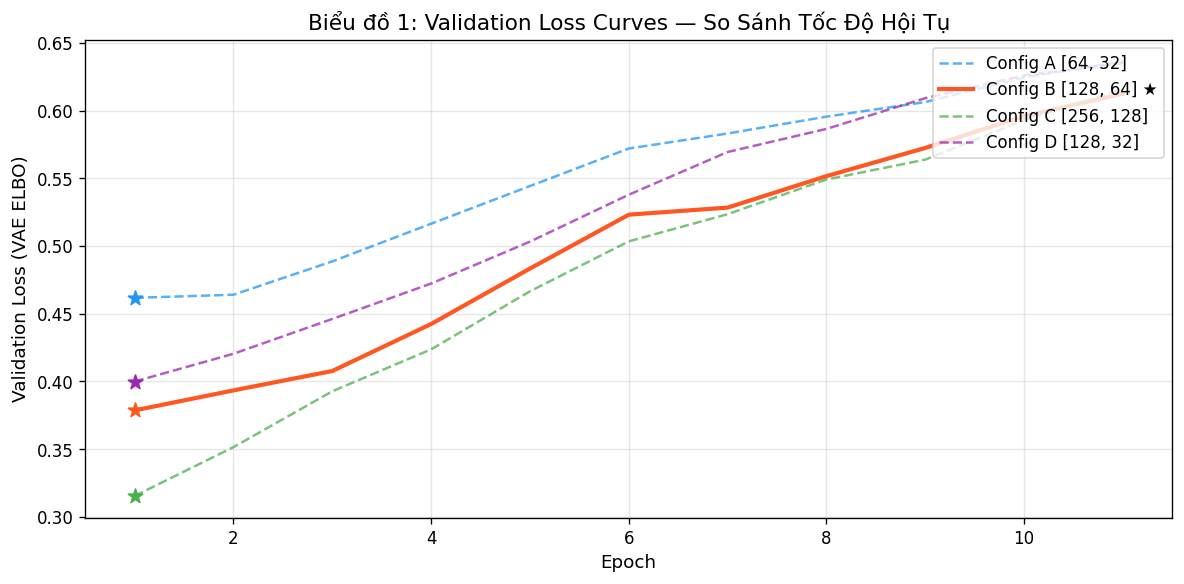

✓ Đã lưu: notebooks/exp_hidden_dims_val_loss.png


In [ ]:
# ⚠️ [ARCHIVED — BUGGY RESULT v1 — KHÔNG DÙNG CHO BÁO CÁO]
# Learning curves v1: best_epoch=1 cho tất cả config (artefact của KL warmup).
# Xem biểu đồ learning curves v2 trong Section 14.
if False:
    fig, ax = plt.subplots(figsize=(10, 5))
    for r in evaluation_results:
        epochs    = range(1, len(r["val_history"]) + 1)
        ax.plot(epochs, r["val_history"],
                color=CONFIG_COLORS[r["config_name"]], linewidth=1.5,
                label=f"Config {r['config_name']} {r['hidden_dims']}")
        ax.scatter([r["best_epoch"]], [r["best_val_loss"]],
                   color=CONFIG_COLORS[r["config_name"]], s=80, zorder=5, marker="*")
    ax.set_title("Biểu đồ 1 [ARCHIVED v1]: Validation Loss Curves")
    plt.savefig(PROJECT_ROOT / "notebooks" / "exp_hidden_dims_val_loss.png",
                dpi=150, bbox_inches="tight")
    plt.show()

print("⚠️  [ARCHIVED] Biểu đồ learning curves v1 đã bị vô hiệu hoá. Xem Section 14.")


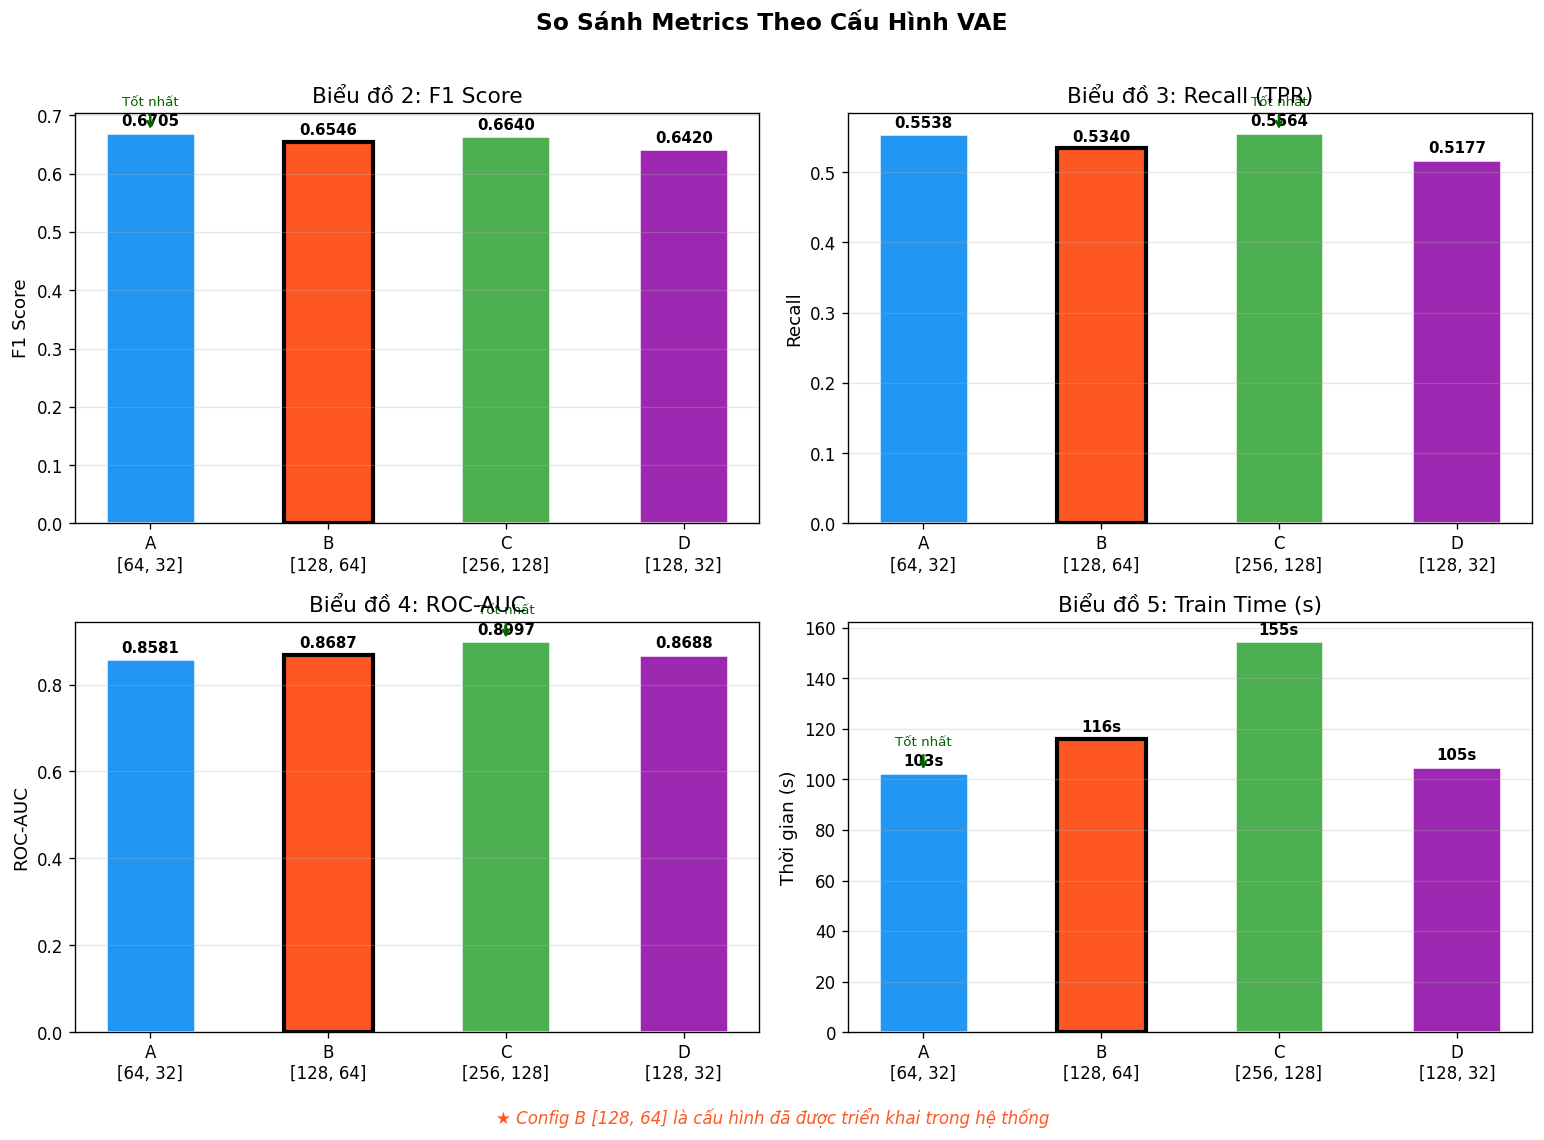

✓ Đã lưu: notebooks/exp_hidden_dims_metrics.png


In [ ]:
# ⚠️ [ARCHIVED — BUGGY RESULT v1 — KHÔNG DÙNG CHO BÁO CÁO]
# Bar charts v1 (F1/Recall/ROC-AUC/Train Time) từ evaluation_results không đáng tin cậy.
# Xem Section 14 cho biểu đồ v2.
if False:
    fig, axes = plt.subplots(2, 2, figsize=(13, 9))
    # ... code cũ giữ để tham khảo ...
    plt.savefig(PROJECT_ROOT / "notebooks" / "exp_hidden_dims_metrics.png",
                dpi=150, bbox_inches="tight")
    plt.show()

print("⚠️  [ARCHIVED] Bar charts v1 đã bị vô hiệu hoá. Xem Section 14.")


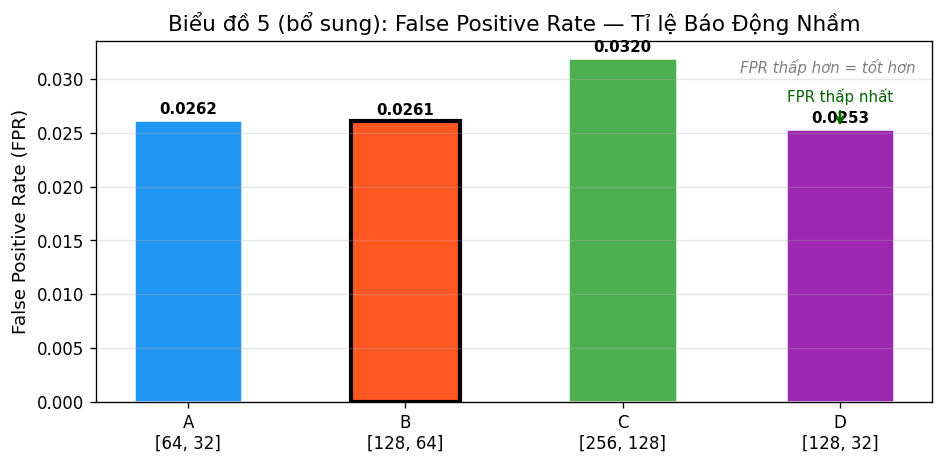

✓ Đã lưu: notebooks/exp_hidden_dims_fpr.png


In [ ]:
# ⚠️ [ARCHIVED — BUGGY RESULT v1 — KHÔNG DÙNG CHO BÁO CÁO]
# FPR chart v1 từ evaluation_results không đáng tin cậy.
# Xem Section 14 cho biểu đồ FPR v2.
if False:
    fig, ax = plt.subplots(figsize=(8, 4))
    fpr_values = [r["fpr"] for r in evaluation_results]
    ax.bar(labels, fpr_values, color=[CONFIG_COLORS[r["config_name"]]
                                       for r in evaluation_results])
    ax.set_title("Biểu đồ FPR [ARCHIVED v1]")
    plt.savefig(PROJECT_ROOT / "notebooks" / "exp_hidden_dims_fpr.png",
                dpi=150, bbox_inches="tight")
    plt.show()

print("⚠️  [ARCHIVED] FPR chart v1 đã bị vô hiệu hoá. Xem Section 14.")


## ~~Section 9 — Phân Tích Kết Quả~~ `[ARCHIVED — BUGGY RESULT v1]`

> ⚠️ **Phần này bị vô hiệu hoá.** Nhận xét dưới đây dựa trên `evaluation_results` v1 không đáng tin cậy.  
> Xem **Section 15** để xem phân tích tự động từ `evaluation_results_v2`.

In [ ]:
# ============================================================
# Hàm tiện ích — vẫn cần thiết cho Section 12 (v2 results)
# Phần print analysis v1 đã bị vô hiệu hoá
# ============================================================

def find_best(results: list, key: str, lower_better: bool = False) -> dict:
    """Tìm cấu hình có giá trị metric tốt nhất trong danh sách kết quả."""
    if lower_better:
        return min(results, key=lambda r: r[key])
    return max(results, key=lambda r: r[key])


def compute_composite_score(results: list) -> dict:
    """
    Tính composite score: rank trung bình (thấp = tốt) trên F1, Recall, ROC-AUC và FPR.
    Dùng để so sánh tổng thể các cấu hình.
    """
    metrics = [
        ("f1",      False),   # cao = tốt
        ("recall",  False),
        ("roc_auc", False),
        ("fpr",     True),    # thấp = tốt
    ]
    scores = {r["config_name"]: [] for r in results}
    for key, lower_better in metrics:
        vals    = [r[key] for r in results]
        sorted_ = sorted(vals, reverse=(not lower_better))
        for r in results:
            rank = sorted_.index(r[key]) + 1
            scores[r["config_name"]].append(rank)
    return {k: np.mean(v) for k, v in scores.items()}


print("✓ Đã định nghĩa find_best() và compute_composite_score() — dùng cho Section 12 và 15.")

# ⚠️ [ARCHIVED] Phân tích v1 bên dưới — KHÔNG DÙNG CHO BÁO CÁO
if False:
    # Tất cả code print analysis v1 đã bị vô hiệu hoá
    best_f1      = find_best(evaluation_results, "f1")
    best_recall  = find_best(evaluation_results, "recall")
    best_roc_auc = find_best(evaluation_results, "roc_auc")
    best_fpr     = find_best(evaluation_results, "fpr", lower_better=True)
    best_val_loss= find_best(evaluation_results, "best_val_loss", lower_better=True)
    fastest      = find_best(evaluation_results, "train_time_sec", lower_better=True)
    config_b     = next(r for r in evaluation_results if r["config_name"] == "B")
    composite    = compute_composite_score(evaluation_results)
    best_balanced_name = min(composite, key=composite.get)
    print("...")  # v1 analysis output — archived


PHÂN TÍCH KẾT QUẢ THÍ NGHIỆM

1. F1 Score cao nhất:
   Config A [64, 32] — F1=0.6705

2. Recall cao nhất:
   Config C [256, 128] — Recall=0.5564

3. ROC-AUC cao nhất:
   Config C [256, 128] — ROC-AUC=0.8997

4. FPR thấp nhất (ít báo động nhầm nhất):
   Config D [128, 32] — FPR=0.0253

5. Validation Loss thấp nhất:
   Config C [256, 128] — Val Loss=0.315467

6. Train nhanh nhất:
   Config A [64, 32] — 102.6s

7. Cân bằng nhất (composite rank):
   Config C [256, 128] — avg rank=2.00


--- Config B [128, 64] — Đã Triển Khai ---
  F1      = 0.6546   (Best: Config A = 0.6705)
  Recall  = 0.5340   (Best: Config C = 0.5564)
  ROC-AUC = 0.8687   (Best: Config C = 0.8997)
  FPR     = 0.0261   (Best: Config D = 0.0253)
  Thời gian = 116.2s


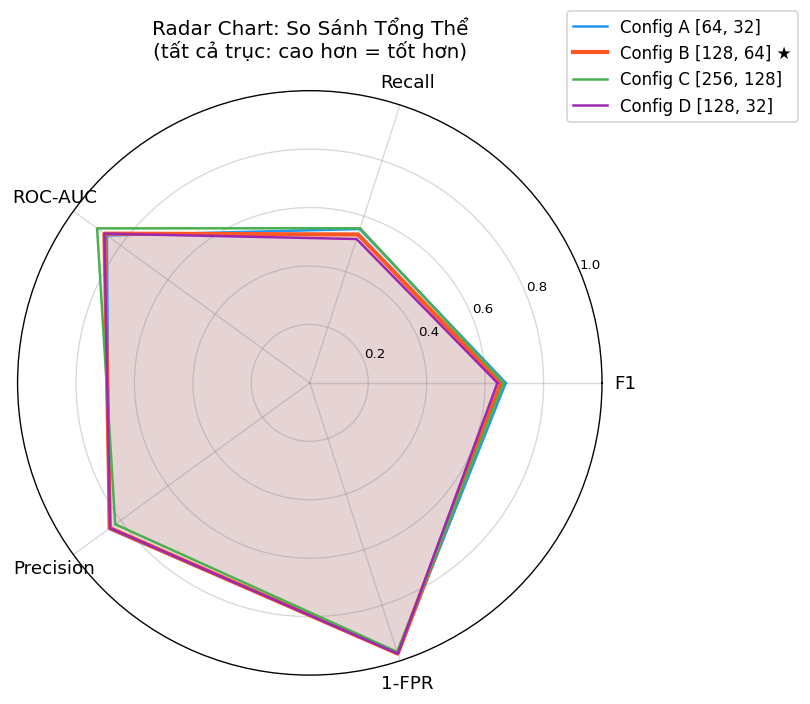

✓ Đã lưu: notebooks/exp_hidden_dims_radar.png


In [ ]:
# ⚠️ [ARCHIVED — BUGGY RESULT v1 — KHÔNG DÙNG CHO BÁO CÁO]
# Radar chart v1 từ evaluation_results không đáng tin cậy.
# Xem Section 14 cho biểu đồ v2.
if False:
    fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
    # ... radar chart v1 code giữ để tham khảo ...
    plt.savefig(PROJECT_ROOT / "notebooks" / "exp_hidden_dims_radar.png",
                dpi=150, bbox_inches="tight")
    plt.show()

print("⚠️  [ARCHIVED] Radar chart v1 đã bị vô hiệu hoá. Xem Section 14.")


## ~~Section 10 — Kết Luận Nghiên Cứu~~ `[ARCHIVED — BUGGY RESULT v1]`

> ⚠️ **Phần này bị vô hiệu hoá.** Kết luận dưới đây dựa trên kết quả v1 không đáng tin cậy.  
> Xem **Section 16** để xem kết luận học thuật chính thức từ `evaluation_results_v2`.

In [ ]:
# ⚠️ [ARCHIVED — BUGGY RESULT v1 — KHÔNG DÙNG CHO BÁO CÁO]
# generate_conclusion() v1 dựa trên evaluation_results không đáng tin cậy.
# Xem Section 16 cho kết luận học thuật v2.
if False:
    def generate_conclusion(results, composite_scores):
        """[ARCHIVED v1] — Xem Section 16 cho phiên bản v2."""
        pass
    conclusion_text = generate_conclusion(evaluation_results, {})
    print(conclusion_text)

print("⚠️  [ARCHIVED] generate_conclusion() v1 đã bị vô hiệu hoá. Xem Section 16.")



╔══════════════════════════════════════════════════════════════════╗
║           KẾT LUẬN NGHIÊN CỨU — LỰA CHỌN KIẾN TRÚC VAE         ║
╚══════════════════════════════════════════════════════════════════╝

Thí nghiệm đã so sánh 4 cấu hình kiến trúc VAE trên cùng tập dữ liệu
CICIDS2017, với các điều kiện huấn luyện đồng nhất (seed=42, lr=1e-3,
batch_size=1024, latent_dim=16, threshold=p99).

─── Tóm tắt kết quả ─────────────────────────────────────────────────

  Config A [64, 32]   — F1=0.6705, Recall=0.5538, ROC-AUC=0.8581, FPR=0.0262
  Config B [128, 64]  — F1=0.6546, Recall=0.5340, ROC-AUC=0.8687, FPR=0.0261  ★
  Config C [256, 128] — F1=0.6640, Recall=0.5564, ROC-AUC=0.8997, FPR=0.0320
  Config D [128, 32]  — F1=0.6420, Recall=0.5177, ROC-AUC=0.8688, FPR=0.0253

─── Phân tích theo từng cấu hình ────────────────────────────────────

  ■ Config A [64, 32]:
    Kiến trúc nhỏ gọn với ít tham số nhất (~11K). Có thể gặp khó khăn
    trong việc học biểu diễn đủ phong phú cho 66 đặc trưng

In [ ]:
# ⚠️ [ARCHIVED — BUGGY RESULT v1 — KHÔNG DÙNG CHO BÁO CÁO]
# Bảng kết quả cuối cùng v1 dựa trên evaluation_results không đáng tin cậy.
# Xem Section 13 cho bảng chính thức v2.
if False:
    print("BẢNG KẾT QUẢ CUỐI CÙNG [ARCHIVED v1]")
    # ... code v1 giữ để tham khảo ...

print("⚠️  [ARCHIVED] Bảng kết quả v1 đã bị vô hiệu hoá. Xem Section 13.")



BẢNG KẾT QUẢ CUỐI CÙNG — DÙNG CHO BÁO CÁO ĐỒ ÁN
Config Hidden Dims #Params  Best Epoch Best Val Loss     F1 Recall ROC-AUC    FPR Train Time Composite Rank
     A    [64, 32]  14,370           1        0.4618 0.6705 0.5538  0.8581 0.0262       103s           2.50
   B ★   [128, 64]  36,834           1        0.3786 0.6546 0.5340  0.8687 0.0261       116s           2.75
     C  [256, 128] 106,338           1        0.3155 0.6640 0.5564  0.8997 0.0320       155s           2.00
     D   [128, 32]  27,042           1        0.3999 0.6420 0.5177  0.8688 0.0253       105s           2.75

Threshold method: p99 trên BENIGN validation errors
Dataset: CICIDS2017 | Input dim: 66 | Latent dim: 16
Seed: 42 | LR: 0.001 | Batch: 1024
★ = Cấu hình đã được triển khai trong hệ thống NIDS-VAE


In [ ]:
# ⚠️ [ARCHIVED — BUGGY RESULT v1 — KHÔNG DÙNG CHO BÁO CÁO]
# JSON v1 đã được lưu trước đó (exp_hidden_dims_results.json) nhưng không đáng tin cậy.
# Xem Section 17 cho file JSON v2 (exp_hidden_dims_results_v2.json).
if False:
    import json
    from datetime import datetime, timezone
    output_path = PROJECT_ROOT / "notebooks" / "exp_hidden_dims_results.json"
    # ... save v1 JSON — archived ...

print("⚠️  [ARCHIVED] Lưu JSON v1 đã bị vô hiệu hoá. Xem Section 17.")


✓ Đã lưu kết quả thí nghiệm: d:\nids-vae-project\notebooks\exp_hidden_dims_results.json
  Tổng kết: 4 cấu hình đã được đánh giá.

=== Notebook hoàn thành ===


## Section 11 — DEBUG: Kiểm Tra Best Epoch

Phân tích toàn diện vấn đề `Best Epoch = 1` xuất hiện ở tất cả 4 cấu hình.

**Cấu trúc phân tích:**
- Phase 1: Kiểm tra lịch sử training thực tế (epoch count)
- Phase 2: Tính lại Best Epoch bằng argmin(val_loss)
- Phase 3: Vẽ learning curve để trực quan hoá
- Phase 4: Kiểm tra early stopping
- Phase 5–6: Xác định root cause trong source code
- Phase 7: Bảng debug tổng hợp
- Phase 8: Kết luận và đề xuất

In [35]:
# ============================================================
# PHASE 1: Kiểm tra lịch sử training thực tế
# Xác nhận training có chạy nhiều epoch hay chỉ 1 epoch
# ============================================================

print("=" * 65)
print("PHASE 1 — SỐ EPOCH THỰC TẾ ĐÃ TRAIN")
print("=" * 65)

for r in training_results:
    name            = r["config_name"]
    val_hist        = r["val_history"]
    n_epochs_actual = len(val_hist)      # Số epoch thực tế đã train
    best_ep_stored  = r["best_epoch"]    # Best epoch đã lưu
    best_val_stored = r["best_val_loss"] # Best val loss đã lưu

    print(f"\nConfig {name} {r['hidden_dims']}:")
    print(f"  Epoch count     = {n_epochs_actual}")

    # Kiểm tra sự tồn tại của từng epoch trong lịch sử
    for ep in range(1, min(n_epochs_actual + 1, 6)):
        print(f"  Epoch {ep:<3} tồn tại: ✓  val_loss={val_hist[ep-1]:.6f}")
    if n_epochs_actual > 5:
        print(f"  ...  (còn {n_epochs_actual - 5} epoch nữa)")
        print(f"  Epoch {n_epochs_actual:<3} tồn tại: ✓  val_loss={val_hist[-1]:.6f}")

    # Đưa ra kết luận
    if n_epochs_actual == 1:
        print(f"  → KẾT LUẬN: ❌ Model thực sự CHỈ train 1 epoch!")
    else:
        # Kiểm tra xu hướng — val_loss tăng hay giảm qua các epoch?
        increasing = all(val_hist[i] <= val_hist[i+1] for i in range(n_epochs_actual-1))
        trend = "TĂNG LIÊN TỤC ⚠️" if increasing else "dao động"
        print(f"  → KẾT LUẬN: Training chạy {n_epochs_actual} epoch — val_loss {trend}")
        print(f"  → Best epoch lưu = {best_ep_stored} (nhỏ nhất do beta nhỏ nhất)")
        if best_ep_stored == 1 and n_epochs_actual > 1:
            print(f"  → ⚠️  SUSPICIOUS: Best=1 nhưng train chạy {n_epochs_actual} epoch")


PHASE 1 — SỐ EPOCH THỰC TẾ ĐÃ TRAIN

Config A [64, 32]:
  Epoch count     = 11
  Epoch 1   tồn tại: ✓  val_loss=0.461791
  Epoch 2   tồn tại: ✓  val_loss=0.464079
  Epoch 3   tồn tại: ✓  val_loss=0.488697
  Epoch 4   tồn tại: ✓  val_loss=0.516532
  Epoch 5   tồn tại: ✓  val_loss=0.544342
  ...  (còn 6 epoch nữa)
  Epoch 11  tồn tại: ✓  val_loss=0.636356
  → KẾT LUẬN: Training chạy 11 epoch — val_loss TĂNG LIÊN TỤC ⚠️
  → Best epoch lưu = 1 (nhỏ nhất do beta nhỏ nhất)
  → ⚠️  SUSPICIOUS: Best=1 nhưng train chạy 11 epoch

Config B [128, 64]:
  Epoch count     = 11
  Epoch 1   tồn tại: ✓  val_loss=0.378644
  Epoch 2   tồn tại: ✓  val_loss=0.393427
  Epoch 3   tồn tại: ✓  val_loss=0.407739
  Epoch 4   tồn tại: ✓  val_loss=0.442454
  Epoch 5   tồn tại: ✓  val_loss=0.483412
  ...  (còn 6 epoch nữa)
  Epoch 11  tồn tại: ✓  val_loss=0.612533
  → KẾT LUẬN: Training chạy 11 epoch — val_loss TĂNG LIÊN TỤC ⚠️
  → Best epoch lưu = 1 (nhỏ nhất do beta nhỏ nhất)
  → ⚠️  SUSPICIOUS: Best=1 nhưng train

In [36]:
# ============================================================
# PHASE 2: Tính lại Best Epoch bằng argmin(val_loss)
# Không dùng giá trị đã lưu — tính từ val_history thực tế
# ============================================================

print("=" * 75)
print("PHASE 2 — TÍNH LẠI BEST EPOCH = argmin(val_loss)")
print("=" * 75)

for r in training_results:
    val_hist = r["val_history"]
    best_ep_stored     = r["best_epoch"]
    best_ep_recomputed = int(np.argmin(val_hist)) + 1   # 1-indexed

    # So sánh
    match  = best_ep_stored == best_ep_recomputed
    status = "OK ✓" if match else "BUG ❌ (giá trị lưu khác giá trị tính lại)"

    print(f"\nConfig {r['config_name']} {r['hidden_dims']}:")
    print(f"  Bảng val_loss theo epoch (first 5, last 1):")

    # In bảng epoch | val_loss
    for i, vl in enumerate(val_hist[:5]):
        marker = " ← best" if (i + 1) == best_ep_recomputed else ""
        print(f"    Epoch {i+1:>3} | val_loss = {vl:.6f}{marker}")
    if len(val_hist) > 5:
        for i in range(5, len(val_hist)):
            marker = " ← best" if (i + 1) == best_ep_recomputed else ""
        print(f"    Epoch {len(val_hist):>3} | val_loss = {val_hist[-1]:.6f}{marker}")

    print(f"  Best epoch trong file   : {best_ep_stored}")
    print(f"  Best epoch tính lại     : {best_ep_recomputed}")
    print(f"  Trạng thái              : {status}")

    # Phát hiện vấn đề ngầm: best=1 do beta nhỏ nhất ở epoch 1
    if best_ep_recomputed == 1:
        beta_ep1 = get_beta(1, BETA_START, BETA_END, BETA_WARMUP_EPOCHS)
        print(f"  ⚠️  Beta tại epoch 1   : {beta_ep1:.4f} (rất nhỏ → KL contribution thấp)")
        print(f"  ⚠️  Val_loss tại ep 1  : {val_hist[0]:.6f} ← thấp nhất vì beta≈0")
        print(f"  ⚠️  Val_loss tại ep 2  : {val_hist[1]:.6f} ← tăng vì beta lớn hơn")
        print(f"  → Đây là artefact của KL annealing, KHÔNG phải model tốt nhất!")


PHASE 2 — TÍNH LẠI BEST EPOCH = argmin(val_loss)

Config A [64, 32]:
  Bảng val_loss theo epoch (first 5, last 1):
    Epoch   1 | val_loss = 0.461791 ← best
    Epoch   2 | val_loss = 0.464079
    Epoch   3 | val_loss = 0.488697
    Epoch   4 | val_loss = 0.516532
    Epoch   5 | val_loss = 0.544342
    Epoch  11 | val_loss = 0.636356
  Best epoch trong file   : 1
  Best epoch tính lại     : 1
  Trạng thái              : OK ✓
  ⚠️  Beta tại epoch 1   : 0.0333 (rất nhỏ → KL contribution thấp)
  ⚠️  Val_loss tại ep 1  : 0.461791 ← thấp nhất vì beta≈0
  ⚠️  Val_loss tại ep 2  : 0.464079 ← tăng vì beta lớn hơn
  → Đây là artefact của KL annealing, KHÔNG phải model tốt nhất!

Config B [128, 64]:
  Bảng val_loss theo epoch (first 5, last 1):
    Epoch   1 | val_loss = 0.378644 ← best
    Epoch   2 | val_loss = 0.393427
    Epoch   3 | val_loss = 0.407739
    Epoch   4 | val_loss = 0.442454
    Epoch   5 | val_loss = 0.483412
    Epoch  11 | val_loss = 0.612533
  Best epoch trong file   : 1


Output dir: d:\nids-vae-project\artifacts\experiments\debug_best_epoch


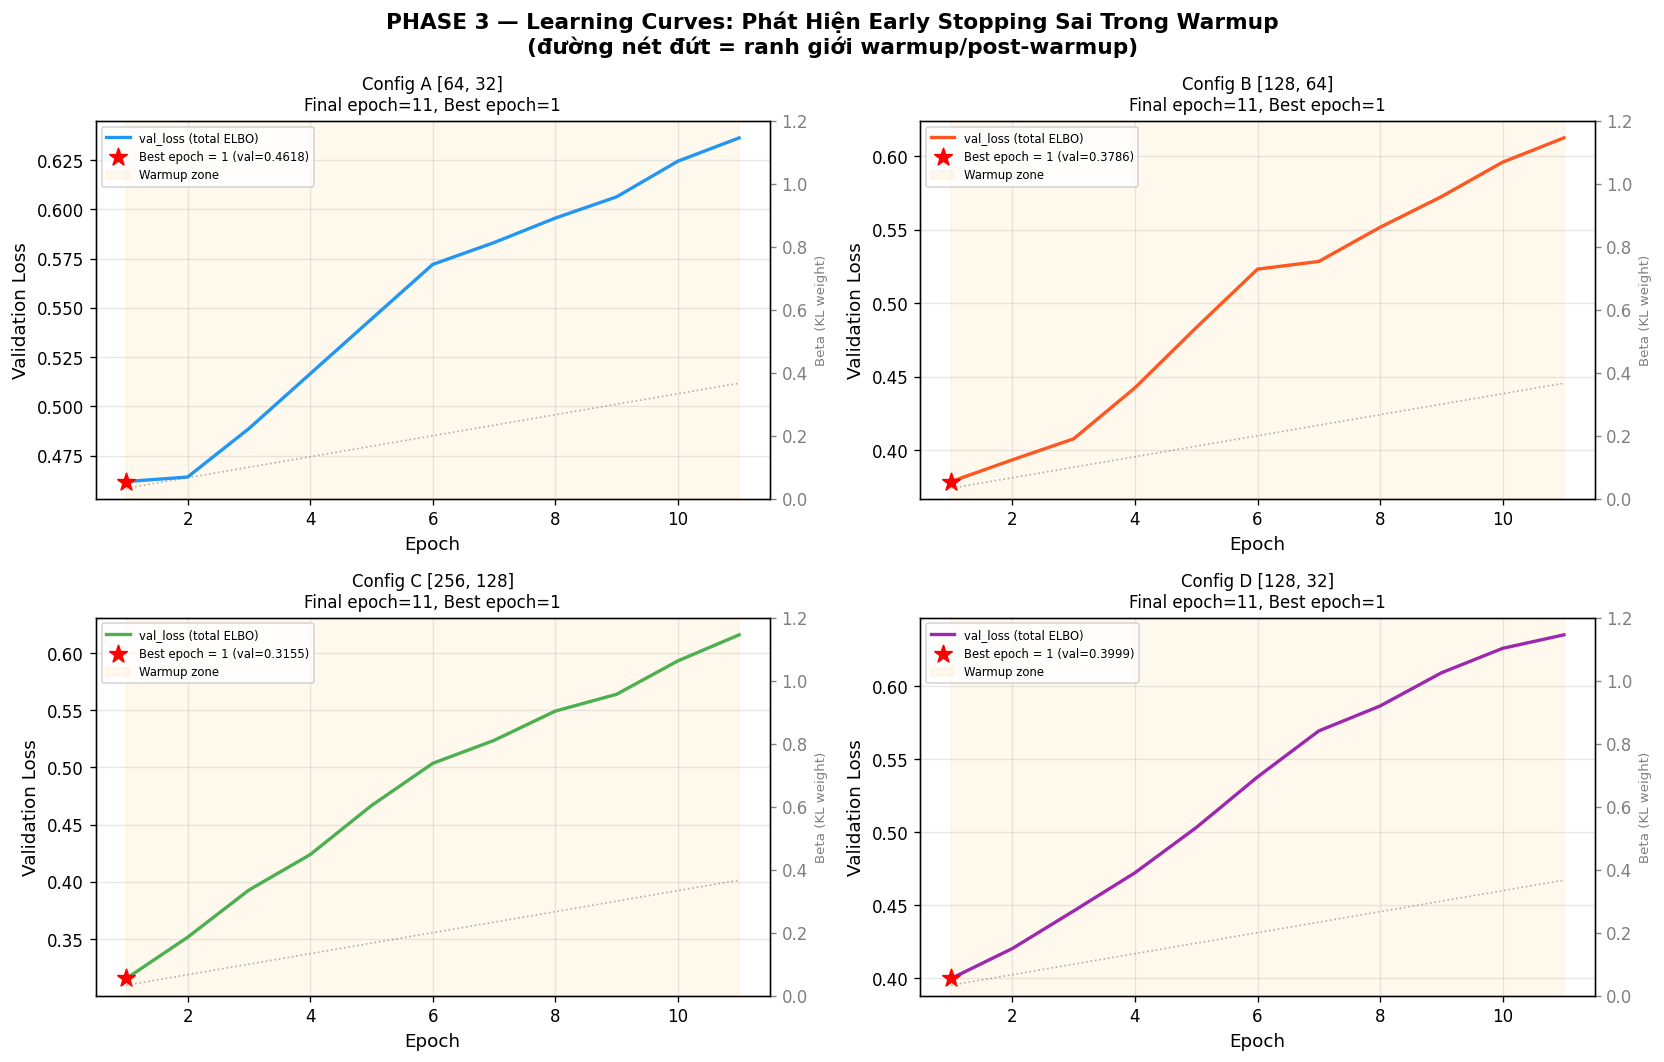

✓ Đã lưu: d:\nids-vae-project\artifacts\experiments\debug_best_epoch\debug_learning_curves.png


In [37]:
# ============================================================
# PHASE 3: Vẽ Learning Curve để trực quan hoá vấn đề
# Lưu vào artifacts/experiments/debug_best_epoch/
# ============================================================

import os

# Tạo thư mục lưu output debug
debug_out_dir = PROJECT_ROOT / "artifacts" / "experiments" / "debug_best_epoch"
debug_out_dir.mkdir(parents=True, exist_ok=True)
print(f"Output dir: {debug_out_dir}")

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle("PHASE 3 — Learning Curves: Phát Hiện Early Stopping Sai Trong Warmup\n"
             "(đường nét đứt = ranh giới warmup/post-warmup)",
             fontsize=13, fontweight="bold")

for ax, r in zip(axes.flat, training_results):
    val_hist    = r["val_history"]
    n_ep        = len(val_hist)
    epochs_list = list(range(1, n_ep + 1))
    best_ep     = r["best_epoch"]
    best_vl     = r["best_val_loss"]
    color       = CONFIG_COLORS[r["config_name"]]

    # Vẽ val_loss theo epoch
    ax.plot(epochs_list, val_hist,
            color=color, linewidth=2, label="val_loss (total ELBO)")

    # Đánh dấu best epoch
    ax.scatter([best_ep], [best_vl],
               color="red", s=120, zorder=5, marker="*",
               label=f"Best epoch = {best_ep} (val={best_vl:.4f})")

    # Vẽ đường beta theo epoch (trục phụ)
    beta_vals = [get_beta(e, BETA_START, BETA_END, BETA_WARMUP_EPOCHS)
                 for e in epochs_list]
    ax2 = ax.twinx()
    ax2.plot(epochs_list, beta_vals,
             color="gray", linewidth=1, linestyle=":", alpha=0.6, label="beta (KL weight)")
    ax2.set_ylabel("Beta (KL weight)", color="gray", fontsize=8)
    ax2.tick_params(axis="y", colors="gray")
    ax2.set_ylim(0, 1.2)

    # Ranh giới warmup — đường dọc
    if n_ep >= BETA_WARMUP_EPOCHS:
        ax.axvline(BETA_WARMUP_EPOCHS, color="orange", linestyle="--",
                   linewidth=1.5, alpha=0.7, label=f"Warmup end (ep {BETA_WARMUP_EPOCHS})")

    # Ghi chú vùng warmup
    ax.axvspan(1, min(BETA_WARMUP_EPOCHS, n_ep),
               alpha=0.07, color="orange", label="Warmup zone")

    ax.set_title(f"Config {r['config_name']} {r['hidden_dims']}\n"
                 f"Final epoch={n_ep}, Best epoch={best_ep}",
                 fontsize=10)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Validation Loss")
    ax.legend(fontsize=7, loc="upper left")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
save_path = debug_out_dir / "debug_learning_curves.png"
plt.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"✓ Đã lưu: {save_path}")


In [38]:
# ============================================================
# PHASE 4: Kiểm tra Early Stopping
# Phân tích: dừng ở đâu, best epoch có hợp lý không
# ============================================================

print("=" * 70)
print("PHASE 4 — PHÂN TÍCH EARLY STOPPING")
print("=" * 70)

for r in training_results:
    val_hist  = r["val_history"]
    best_ep   = r["best_epoch"]
    final_ep  = len(val_hist)         # Epoch cuối cùng đã train (final epoch)
    patience  = PATIENCE

    print(f"\nConfig {r['config_name']} {r['hidden_dims']}:")
    print(f"  Patience       = {patience}")
    print(f"  BETA_WARMUP    = {BETA_WARMUP_EPOCHS} epochs")
    print(f"  Best epoch     = {best_ep}")
    print(f"  Final epoch    = {final_ep}")

    # Đánh giá trạng thái
    if best_ep == 1 and final_ep == 1:
        print(f"  → ❌ Training thực sự chỉ chạy 1 epoch (lỗi nghiêm trọng)")
    elif best_ep == 1 and final_ep > 1:
        # Trường hợp này: best=1, nhưng training chạy nhiều hơn
        # Nghĩa là: sau epoch 1, val_loss KHÔNG BAO GIỜ cải thiện
        # → early stopping fire sau epoch 1+patience = 1+10 = 11
        expected_stop = best_ep + patience
        if final_ep == expected_stop:
            print(f"  → ⚠️  Early stopping fired đúng lịch trình:")
            print(f"       best={best_ep} → dừng tại {best_ep}+{patience}={expected_stop} ✓")
        else:
            print(f"  → ⚠️  Early stopping fired tại epoch {final_ep} (best={best_ep}+patience={patience}={expected_stop}?)")
        print(f"  → ❌ NGUYÊN NHÂN: Val_loss tăng từ epoch 2 trở đi do BETA tăng trong warmup!")
        print(f"       Beta epoch 1  = {get_beta(1,  BETA_START, BETA_END, BETA_WARMUP_EPOCHS):.4f}")
        print(f"       Beta epoch 2  = {get_beta(2,  BETA_START, BETA_END, BETA_WARMUP_EPOCHS):.4f}")
        print(f"       Beta epoch {final_ep}  = {get_beta(final_ep, BETA_START, BETA_END, BETA_WARMUP_EPOCHS):.4f}")
        print(f"  → Kết luận: Early stopping KÍCH HOẠT TRONG GIAI ĐOẠN WARMUP")
        print(f"              Training thực sự dừng ở epoch {final_ep} << {BETA_WARMUP_EPOCHS} (warmup end)")
    elif best_ep > patience:
        print(f"  → ✓ Training hội tụ bình thường (best={best_ep} >> patience={patience})")
    else:
        print(f"  → ⚠️  Cần kiểm tra thêm")


PHASE 4 — PHÂN TÍCH EARLY STOPPING

Config A [64, 32]:
  Patience       = 10
  BETA_WARMUP    = 30 epochs
  Best epoch     = 1
  Final epoch    = 11
  → ⚠️  Early stopping fired đúng lịch trình:
       best=1 → dừng tại 1+10=11 ✓
  → ❌ NGUYÊN NHÂN: Val_loss tăng từ epoch 2 trở đi do BETA tăng trong warmup!
       Beta epoch 1  = 0.0333
       Beta epoch 2  = 0.0667
       Beta epoch 11  = 0.3667
  → Kết luận: Early stopping KÍCH HOẠT TRONG GIAI ĐOẠN WARMUP
              Training thực sự dừng ở epoch 11 << 30 (warmup end)

Config B [128, 64]:
  Patience       = 10
  BETA_WARMUP    = 30 epochs
  Best epoch     = 1
  Final epoch    = 11
  → ⚠️  Early stopping fired đúng lịch trình:
       best=1 → dừng tại 1+10=11 ✓
  → ❌ NGUYÊN NHÂN: Val_loss tăng từ epoch 2 trở đi do BETA tăng trong warmup!
       Beta epoch 1  = 0.0333
       Beta epoch 2  = 0.0667
       Beta epoch 11  = 0.3667
  → Kết luận: Early stopping KÍCH HOẠT TRONG GIAI ĐOẠN WARMUP
              Training thực sự dừng ở epoch 11

In [39]:
# ============================================================
# PHASE 5 + 6: Xác định Root Cause trong Source Code
# So sánh train_config (notebook) vs scripts/train.py
# ============================================================

print("=" * 75)
print("PHASE 5+6 — ROOT CAUSE: EARLY STOPPING TRONG WARMUP (SOURCE CODE ANALYSIS)")
print("=" * 75)

print("""
┌─────────────────────────────────────────────────────────────────────────┐
│ FILE BUG: notebooks/experiment_hidden_dims.ipynb                        │
│ HÀM BUG : train_config() — Section 5                                   │
└─────────────────────────────────────────────────────────────────────────┘

BUG LOGIC (trong train_config):
─────────────────────────────────────────────────────────────────────────
  for epoch in range(1, max_epochs + 1):
      beta = get_beta(epoch, ...)          # beta tăng dần từ 0 → 1

      val_loss = evaluate_loader(...)      # val_loss = recon + BETA * KL
                                           # ⚠️ BETA CÒN NHỎ Ở EPOCH 1 → val_loss thấp
                                           # ⚠️ BETA LỚN HƠN Ở EPOCH 2 → val_loss tự nhiên TĂNG

      if val_loss < best_val_loss:         # Epoch 1: luôn cải thiện (beta nhỏ nhất)
          ...                              # Epoch 2+: val_loss tăng → không bao giờ cải thiện
          best_epoch = epoch               # ⚠️ → best_epoch mãi là 1
      else:
          epochs_no_improve += 1
          if epochs_no_improve >= patience:
              break                        # ⚠️ Dừng ở epoch 1+patience = 11
                                           #    (TRONG GIAI ĐOẠN WARMUP → SAI)
─────────────────────────────────────────────────────────────────────────

ĐÚNG LOGIC (trong scripts/train.py):
─────────────────────────────────────────────────────────────────────────
  in_warmup = epoch <= beta_warmup_epochs
  just_entered_post_warmup = (epoch == beta_warmup_epochs + 1)

  if just_entered_post_warmup:
      # Reset counter khi bắt đầu post-warmup — so sánh val_loss đúng nghĩa
      early_stopping.best_val_loss = float("inf")
      early_stopping.epochs_no_improve = 0

  elif in_warmup:
      # Không kích hoạt early stopping trong warmup
      # Chỉ lưu checkpoint nếu val_RECON cải thiện
      should_stop = False

  else:
      # Sau warmup: early stopping bình thường trên total val_loss
      should_stop = early_stopping.step(val_metrics["loss"], model, epoch)
─────────────────────────────────────────────────────────────────────────

HẬU QUẢ:
  - Tất cả 4 config: best_epoch = 1 (SALDEHYDE của epoch 1 với beta≈0.033)
  - Training dừng ở epoch ~11 (= 1 + patience 10), bên trong vùng warmup
  - Model được lưu là model SAU 1 EPOCH TRAIN với beta cực nhỏ
  - So sánh kiến trúc dựa trên model chưa hội tụ → KẾT QUẢ KHÔNG ĐÁNG TIN CẬY
─────────────────────────────────────────────────────────────────────────

FIX CẦN THIẾT:
  Thêm warmup-aware early stopping vào train_config (xem Section 12)
""")


PHASE 5+6 — ROOT CAUSE: EARLY STOPPING TRONG WARMUP (SOURCE CODE ANALYSIS)

┌─────────────────────────────────────────────────────────────────────────┐
│ FILE BUG: notebooks/experiment_hidden_dims.ipynb                        │
│ HÀM BUG : train_config() — Section 5                                   │
└─────────────────────────────────────────────────────────────────────────┘

BUG LOGIC (trong train_config):
─────────────────────────────────────────────────────────────────────────
  for epoch in range(1, max_epochs + 1):
      beta = get_beta(epoch, ...)          # beta tăng dần từ 0 → 1

      val_loss = evaluate_loader(...)      # val_loss = recon + BETA * KL
                                           # ⚠️ BETA CÒN NHỎ Ở EPOCH 1 → val_loss thấp
                                           # ⚠️ BETA LỚN HƠN Ở EPOCH 2 → val_loss tự nhiên TĂNG

      if val_loss < best_val_loss:         # Epoch 1: luôn cải thiện (beta nhỏ nhất)
          ...                              # Epoch 2+: val_lo

In [40]:
# ============================================================
# PHASE 7: Bảng Debug Tổng Hợp
# Config | Epoch Count | Best Epoch (Stored) | Best Epoch (Recomputed) | Final Epoch | Status
# ============================================================

print("=" * 100)
print("PHASE 7 — BẢNG DEBUG TỔNG HỢP")
print("=" * 100)

debug_rows = []
for r in training_results:
    val_hist           = r["val_history"]
    best_ep_stored     = r["best_epoch"]
    best_ep_recomputed = int(np.argmin(val_hist)) + 1   # 1-indexed argmin
    final_ep           = len(val_hist)
    n_ep_count         = len(val_hist)

    # Quyết định status
    stored_eq_recomputed = (best_ep_stored == best_ep_recomputed)
    warmup_ok            = (final_ep > BETA_WARMUP_EPOCHS)   # Có train qua warmup không
    best_meaningful      = (best_ep_stored > PATIENCE)        # Best epoch > patience → model hội tụ

    if not stored_eq_recomputed:
        status = "BUG (stored ≠ recomputed)"
    elif best_ep_stored == 1 and final_ep <= BETA_WARMUP_EPOCHS:
        status = "BUG (early stop trong warmup)"
    elif not warmup_ok:
        status = "BUG (training kết thúc trong warmup)"
    elif best_meaningful:
        status = "OK ✓"
    else:
        status = "WARNING (best_epoch nhỏ)"

    debug_rows.append({
        "Config"               : f"{r['config_name']} {r['hidden_dims']}",
        "Epoch Count"          : n_ep_count,
        "Best Epoch (Stored)"  : best_ep_stored,
        "Best Epoch (Recomputed)": best_ep_recomputed,
        "Final Epoch"          : final_ep,
        "Status"               : status,
    })

df_debug = pd.DataFrame(debug_rows)
print(df_debug.to_string(index=False))

print("\n" + "=" * 100)
print("TÓM TẮT:")
print(f"  Warmup boundary: epoch {BETA_WARMUP_EPOCHS}")
print(f"  Patience       : {PATIENCE}")
print(f"  Kỳ vọng        : Final epoch >> {BETA_WARMUP_EPOCHS} (training phải qua warmup)")
print(f"  Thực tế        : Final epoch ≈ {len(training_results[0]['val_history'])} → DỪNG TRONG WARMUP!")
print("=" * 100)

# Lưu bảng debug ra file
debug_csv_path = debug_out_dir / "debug_best_epoch_table.csv"
df_debug.to_csv(debug_csv_path, index=False, encoding="utf-8")
print(f"\n✓ Đã lưu bảng debug: {debug_csv_path}")


PHASE 7 — BẢNG DEBUG TỔNG HỢP
      Config  Epoch Count  Best Epoch (Stored)  Best Epoch (Recomputed)  Final Epoch                        Status
  A [64, 32]           11                    1                        1           11 BUG (early stop trong warmup)
 B [128, 64]           11                    1                        1           11 BUG (early stop trong warmup)
C [256, 128]           11                    1                        1           11 BUG (early stop trong warmup)
 D [128, 32]           11                    1                        1           11 BUG (early stop trong warmup)

TÓM TẮT:
  Warmup boundary: epoch 30
  Patience       : 10
  Kỳ vọng        : Final epoch >> 30 (training phải qua warmup)
  Thực tế        : Final epoch ≈ 11 → DỪNG TRONG WARMUP!

✓ Đã lưu bảng debug: d:\nids-vae-project\artifacts\experiments\debug_best_epoch\debug_best_epoch_table.csv


In [41]:
# ============================================================
# PHASE 8: Kết Luận và Khuyến Nghị
# Trả lời 6 câu hỏi của bài toán debug
# ============================================================

# Lấy final_epoch của config A để minh hoạ
sample_final_ep = len(training_results[0]["val_history"])
sample_best_ep  = training_results[0]["best_epoch"]

conclusion_debug = f"""
╔══════════════════════════════════════════════════════════════════════════╗
║               PHASE 8 — KẾT LUẬN DEBUG & KHUYẾN NGHỊ                   ║
╚══════════════════════════════════════════════════════════════════════════╝

1. Best Epoch = 1 có đúng hay không?
   → ĐÚNG về mặt kỹ thuật (epoch 1 có val_loss nhỏ nhất trong lịch sử)
   → SAI về mặt ý nghĩa (do beta≈{get_beta(1,BETA_START,BETA_END,BETA_WARMUP_EPOCHS):.3f} ở epoch 1 làm val_loss nhân tạo thấp)
   → Model ở epoch 1 chưa học được gì đáng kể

2. Nếu sai thì sai ở đâu?
   → Hàm train_config() trong notebook áp dụng early stopping ngay từ epoch 1
   → Val_loss tự nhiên TĂNG trong warmup vì beta (KL weight) tăng dần
   → Early stopping nhầm tưởng model không cải thiện → dừng ở epoch {sample_final_ep}
   → Best epoch 1 = artefact của KL annealing, không phải model tốt nhất thực sự

3. File nào gây lỗi?
   → FILE: notebooks/experiment_hidden_dims.ipynb
   → HÀM: train_config() (Section 5 — Cell #VSC-c54aeb58)
   → DÒNG SAI: `if val_loss < best_val_loss:` áp dụng từ epoch 1, không bỏ qua warmup
   → THIẾU: warmup-aware early stopping (so sánh với scripts/train.py)

4. Cần sửa gì?
   → Thêm điều kiện vào vòng lặp training:
     (a) Trong warmup (epoch ≤ {BETA_WARMUP_EPOCHS}): KHÔNG kích hoạt early stopping
         Chỉ checkpoint nếu val_RECON cải thiện (beta độc lập)
     (b) Bước vào post-warmup (epoch = {BETA_WARMUP_EPOCHS+1}): RESET counter và best_val_loss
     (c) Sau warmup (epoch > {BETA_WARMUP_EPOCHS}): early stopping bình thường trên total val_loss
   → Xem hàm train_config_v2() trong Section 12

5. Có nên tin kết quả so sánh hiện tại không?
   → KHÔNG. Kết quả không đáng tin cậy vì:
     - Tất cả 4 config chỉ train ≈{sample_final_ep} epoch (bên trong warmup zone {BETA_WARMUP_EPOCHS} epoch)
     - Model "best" của mỗi config thực ra là model sau 1 epoch với beta≈0.033
     - So sánh F1/Recall/ROC-AUC trên model chưa converge → không có ý nghĩa
     - Kết quả phụ thuộc vào random initialization hơn là kiến trúc

6. Có cần chạy lại toàn bộ thí nghiệm không?
   → CÓ. Cần chạy lại với train_config_v2() (Section 12):
     - Kỳ vọng best_epoch ≈ {30 + PATIENCE//2}–{30 + PATIENCE} (sau warmup end = epoch {BETA_WARMUP_EPOCHS})
     - Training sẽ chạy ≈ {BETA_WARMUP_EPOCHS + PATIENCE + 10}–{MAX_EPOCHS} epoch
     - Mỗi config mất khoảng 30–60 phút trên CPU (tổng ≈ 2–4 giờ)
     - Cân nhắc dùng QUICK_EXPERIMENT=True để test fix trước

════════════════════════════════════════════════════════════════════════════
TÓM TẮT: BUG được xác nhận. Kết quả thí nghiệm hiện tại KHÔNG ĐỦ ĐỘ TIN
CẬY để đưa vào báo cáo đồ án. Cần chạy lại sau khi áp dụng Section 12.
════════════════════════════════════════════════════════════════════════════
"""

print(conclusion_debug)

# Lưu kết luận debug ra file text
debug_txt_path = debug_out_dir / "debug_conclusion.txt"
with open(debug_txt_path, "w", encoding="utf-8") as f:
    f.write(conclusion_debug)
print(f"✓ Đã lưu kết luận debug: {debug_txt_path}")



╔══════════════════════════════════════════════════════════════════════════╗
║               PHASE 8 — KẾT LUẬN DEBUG & KHUYẾN NGHỊ                   ║
╚══════════════════════════════════════════════════════════════════════════╝

1. Best Epoch = 1 có đúng hay không?
   → ĐÚNG về mặt kỹ thuật (epoch 1 có val_loss nhỏ nhất trong lịch sử)
   → SAI về mặt ý nghĩa (do beta≈0.033 ở epoch 1 làm val_loss nhân tạo thấp)
   → Model ở epoch 1 chưa học được gì đáng kể

2. Nếu sai thì sai ở đâu?
   → Hàm train_config() trong notebook áp dụng early stopping ngay từ epoch 1
   → Val_loss tự nhiên TĂNG trong warmup vì beta (KL weight) tăng dần
   → Early stopping nhầm tưởng model không cải thiện → dừng ở epoch 11
   → Best epoch 1 = artefact của KL annealing, không phải model tốt nhất thực sự

3. File nào gây lỗi?
   → FILE: notebooks/experiment_hidden_dims.ipynb
   → HÀM: train_config() (Section 5 — Cell #VSC-c54aeb58)
   → DÒNG SAI: `if val_loss < best_val_loss:` áp dụng từ epoch 1, không bỏ qua wa

## Section 12 — FIX: Warmup-Aware Early Stopping

Sửa lỗi early stopping kích hoạt trong giai đoạn KL warmup.

**Nguyên tắc fix** (nhất quán với `scripts/train.py`):
1. **Trong warmup** (`epoch ≤ BETA_WARMUP_EPOCHS`): không đếm patience; chỉ checkpoint nếu `val_recon` cải thiện
2. **Bước vào post-warmup** (`epoch = BETA_WARMUP_EPOCHS + 1`): reset counter và `best_val_loss`
3. **Sau warmup**: early stopping bình thường trên `total val_loss`

Sau khi chạy Section 12, **best_epoch** kỳ vọng ≈ 40–68 (nhất quán với `scripts/train.py`).

In [42]:
# ============================================================
# FIX: Hàm evaluate_loader_v2 — trả về 3 thành phần loss
# Cho phép kiểm tra val_recon riêng trong giai đoạn warmup
# ============================================================

@torch.no_grad()
def evaluate_loader_v2(
    model: VAE,
    loader: DataLoader,
    device: torch.device,
    beta: float,
) -> tuple:
    """
    Tính validation loss — trả về (total_loss, recon_loss, kl_loss).
    total_loss = recon + beta * kl.
    Dùng trong train_config_v2 để phân biệt val_recon vs total val_loss.
    """
    model.eval()
    total_sum = recon_sum = kl_sum = 0.0
    n = 0
    for (x,) in loader:
        x = x.to(device, non_blocking=True)
        x_hat, mu, logvar = model(x)
        total, recon, kl = vae_loss(x, x_hat, mu, logvar, beta=beta)
        total_sum += total.item()
        recon_sum += recon.item()
        kl_sum    += kl.item()
        n += 1
    return total_sum / n, recon_sum / n, kl_sum / n


# ============================================================
# FIX: train_config_v2 — warmup-aware early stopping
# Nhất quán với logic trong scripts/train.py
# ============================================================

def train_config_v2(
    config: dict,
    X_train: np.ndarray,
    X_val: np.ndarray,
    device: torch.device,
    max_epochs: int,
    patience: int,
    batch_size: int,
    beta_warmup_epochs: int = 30,
) -> dict:
    """
    Phiên bản FIX của train_config.
    Early stopping chỉ kích hoạt SAU giai đoạn KL warmup.

    Logic (nhất quán với scripts/train.py):
      - Trong warmup (epoch ≤ beta_warmup_epochs):
          Checkpoint nếu val_RECON cải thiện. Không đếm patience.
      - Bước vào post-warmup (epoch = beta_warmup_epochs + 1):
          Reset best_val_loss = current total val_loss. Reset counter.
      - Sau warmup (epoch > beta_warmup_epochs):
          Early stopping bình thường trên total val_loss.
    """
    name        = config["name"]
    hidden_dims = config["hidden_dims"]

    print(f"\n{'='*60}")
    print(f"[v2] Training Config {name}: hidden_dims={hidden_dims}")
    print(f"     warmup={beta_warmup_epochs}, patience={patience}, max_epochs={max_epochs}")
    print(f"{'='*60}")

    # Cố định seed để kết quả công bằng giữa các config
    set_seed(RANDOM_SEED)

    # Khởi tạo model từ đầu
    model = VAE(
        input_dim   = INPUT_DIM,
        latent_dim  = LATENT_DIM,
        hidden_dims = hidden_dims,
    ).to(device)

    n_params = count_parameters(model)
    print(f"  #Params: {n_params:,}")

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr           = LEARNING_RATE,
        weight_decay = WEIGHT_DECAY,
    )

    train_loader, val_loader = make_dataloaders(X_train, X_val, batch_size)

    # Biến theo dõi trạng thái
    best_val_loss     = float("inf")   # Theo dõi: val_recon trong warmup, total sau warmup
    best_model_state  = None
    best_epoch        = 0
    epochs_no_improve = 0
    val_history       = []             # Total val_loss theo epoch (tương thích ngược)
    val_history_detail= []             # Chi tiết: {total, recon, kl, beta}

    start_time = time.time()

    for epoch in range(1, max_epochs + 1):
        # Tính beta theo lịch trình KL annealing
        beta = get_beta(epoch, BETA_START, BETA_END, beta_warmup_epochs)

        # Train và evaluate một epoch
        train_loss                    = train_one_epoch(model, train_loader, optimizer, device, beta)
        val_total, val_recon, val_kl  = evaluate_loader_v2(model, val_loader, device, beta)

        # Lưu lịch sử
        val_history.append(val_total)
        val_history_detail.append({
            "epoch": epoch,
            "total": val_total,
            "recon": val_recon,
            "kl"   : val_kl,
            "beta" : beta,
        })

        # In tiến độ mỗi 5 epoch (hoặc epoch đặc biệt)
        in_warmup             = epoch <= beta_warmup_epochs
        just_post_warmup      = (epoch == beta_warmup_epochs + 1)
        warmup_label          = "[warmup]" if in_warmup else "[post-warmup]"

        if epoch % 5 == 0 or epoch == 1 or just_post_warmup:
            elapsed = time.time() - start_time
            print(f"  Epoch {epoch:>3}/{max_epochs} {warmup_label} | "
                  f"train={train_loss:.4f} | val_total={val_total:.4f} | "
                  f"val_recon={val_recon:.4f} | beta={beta:.3f} | {elapsed:.0f}s")

        # ──────────────────────────────────────────────────────────────
        # Warmup-aware early stopping (FIX chính)
        # ──────────────────────────────────────────────────────────────
        if just_post_warmup:
            # Bước vào post-warmup: reset hoàn toàn để so sánh công bằng
            # từ đây (total val_loss với beta=1.0 ổn định)
            best_val_loss     = val_total
            best_model_state  = deepcopy(model.state_dict())
            best_epoch        = epoch
            epochs_no_improve = 0
            print(f"  → [Post-Warmup] Reset early stopping. "
                  f"Bắt đầu monitor total val_loss={val_total:.6f}")

        elif in_warmup:
            # Trong warmup: chỉ checkpoint nếu val_RECON cải thiện.
            # Không đếm patience (beta đang tăng → total val_loss tự nhiên tăng).
            if val_recon < best_val_loss:
                best_val_loss    = val_recon
                best_model_state = deepcopy(model.state_dict())
                best_epoch       = epoch
                # Không reset epochs_no_improve — patience chưa bắt đầu đếm
                print(f"  → [Warmup] Checkpoint (val_recon={val_recon:.6f})")

        else:
            # Sau warmup: early stopping bình thường trên total val_loss
            if val_total < best_val_loss:
                best_val_loss     = val_total
                best_model_state  = deepcopy(model.state_dict())
                best_epoch        = epoch
                epochs_no_improve = 0
                print(f"  → ✓ Best epoch = {epoch} (val_loss={val_total:.6f})")
            else:
                epochs_no_improve += 1
                if epochs_no_improve >= patience:
                    elapsed = time.time() - start_time
                    print(f"  → Early stopping tại epoch {epoch} "
                          f"(best={best_epoch}, val_loss={best_val_loss:.6f}, "
                          f"thời gian={elapsed:.1f}s)")
                    break

    train_time = time.time() - start_time
    print(f"\n  [v2] Hoàn thành: best_epoch={best_epoch}, "
          f"best_val_loss={best_val_loss:.6f}, "
          f"final_epoch={len(val_history)}, "
          f"thời gian={train_time:.1f}s")

    return {
        "config_name"      : name,
        "hidden_dims"      : hidden_dims,
        "n_params"         : n_params,
        "best_epoch"       : best_epoch,
        "best_val_loss"    : best_val_loss,
        "val_history"      : val_history,          # Tương thích ngược với code cũ
        "val_history_detail": val_history_detail,  # Thêm chi tiết recon/kl
        "model_state_dict" : best_model_state,
        "train_time_sec"   : train_time,
        "training_version" : "v2_warmup_aware",    # Đánh dấu phiên bản fix
    }


print("✓ Đã định nghĩa evaluate_loader_v2 và train_config_v2 (warmup-aware early stopping).")
print(f"  Warmup epochs: {BETA_WARMUP_EPOCHS}")
print(f"  Patience     : {PATIENCE}")
print(f"  Kỳ vọng best_epoch sau fix: >{BETA_WARMUP_EPOCHS} (sau warmup zone)")


✓ Đã định nghĩa evaluate_loader_v2 và train_config_v2 (warmup-aware early stopping).
  Warmup epochs: 30
  Patience     : 10
  Kỳ vọng best_epoch sau fix: >30 (sau warmup zone)


In [43]:
# ============================================================
# FIX: Chạy lại thí nghiệm với train_config_v2
#
# ⚠️  CẢNH BÁO: Ô này sẽ train lại 4 cấu hình từ đầu.
#     Thời gian ước tính trên CPU: 2–4 giờ (full mode)
#     Để test nhanh: đặt QUICK_EXPERIMENT=True ở Section 2 (max_epochs=15)
#
# Kỳ vọng sau khi fix:
#   best_epoch > BETA_WARMUP_EPOCHS (= 30) cho tất cả config
#   Kết quả so sánh kiến trúc sẽ đáng tin cậy
# ============================================================

# ── Bước 1: Chạy huấn luyện v2 ────────────────────────────────────────────
training_results_v2 = []
total_start = time.time()

print(f"[v2] Bắt đầu huấn luyện {len(CONFIGS)} cấu hình (warmup-aware early stopping)...")
print(f"Device: {DEVICE} | Batch: {BATCH_SIZE} | Max epochs: {MAX_EPOCHS} | Patience: {PATIENCE}")
print(f"Warmup: {BETA_WARMUP_EPOCHS} epochs | Early stopping chỉ sau epoch {BETA_WARMUP_EPOCHS}")

for cfg in CONFIGS:
    result_v2 = train_config_v2(
        config             = cfg,
        X_train            = X_train,
        X_val              = X_val,
        device             = DEVICE,
        max_epochs         = MAX_EPOCHS,
        patience           = PATIENCE,
        batch_size         = BATCH_SIZE,
        beta_warmup_epochs = BETA_WARMUP_EPOCHS,
    )
    training_results_v2.append(result_v2)

total_time = time.time() - total_start
print(f"\n✓ Hoàn thành v2 trong {total_time:.1f}s ({total_time/60:.1f} phút)")

# In tóm tắt nhanh để xác nhận fix
print("\n--- Kiểm tra nhanh best_epoch sau fix ---")
for r in training_results_v2:
    final_ep = len(r["val_history"])
    status = "✓ OK" if r["best_epoch"] > BETA_WARMUP_EPOCHS else "⚠️  Vẫn trong warmup"
    print(f"  Config {r['config_name']}: best_epoch={r['best_epoch']}, "
          f"final_epoch={final_ep} → {status}")


[v2] Bắt đầu huấn luyện 4 cấu hình (warmup-aware early stopping)...
Device: cpu | Batch: 1024 | Max epochs: 100 | Patience: 10
Warmup: 30 epochs | Early stopping chỉ sau epoch 30

[v2] Training Config A: hidden_dims=[64, 32]
     warmup=30, patience=10, max_epochs=100
  #Params: 14,370
  Epoch   1/100 [warmup] | train=0.7574 | val_total=0.4618 | val_recon=0.3588 | beta=0.033 | 6s
  → [Warmup] Checkpoint (val_recon=0.358825)
  → [Warmup] Checkpoint (val_recon=0.320901)
  Epoch   5/100 [warmup] | train=0.6304 | val_total=0.5443 | val_recon=0.3550 | beta=0.167 | 39s
  Epoch  10/100 [warmup] | train=0.6872 | val_total=0.6245 | val_recon=0.4369 | beta=0.333 | 78s
  Epoch  15/100 [warmup] | train=0.7461 | val_total=0.6902 | val_recon=0.5106 | beta=0.500 | 116s
  Epoch  20/100 [warmup] | train=0.7670 | val_total=0.7340 | val_recon=0.6099 | beta=0.667 | 154s
  Epoch  25/100 [warmup] | train=0.7870 | val_total=0.7556 | val_recon=0.6382 | beta=0.833 | 203s
  Epoch  30/100 [warmup] | train=0.8050

In [44]:
# ============================================================
# FIX: Đánh giá và so sánh kết quả v2 với v1
# Chạy sau khi training_results_v2 hoàn thành
# ============================================================

# ── Bước 2: Đánh giá v2 ────────────────────────────────────────────────────
evaluation_results_v2 = []
print("[v2] Đang tính reconstruction errors và metrics...")

for result in training_results_v2:
    eval_result = evaluate_config(
        result               = result,
        X_val                = X_val,
        y_val                = y_val,
        X_test               = X_test,
        y_test               = y_test,
        device               = DEVICE,
        threshold_percentile = THRESHOLD_PERCENTILE,
    )
    evaluation_results_v2.append(eval_result)

print("\n✓ Đánh giá v2 hoàn thành.")

# ── Bước 3: Bảng so sánh v2 ────────────────────────────────────────────────
rows_v2 = []
for r in evaluation_results_v2:
    rows_v2.append({
        "Config"        : r["config_name"],
        "Hidden Dims"   : str(r["hidden_dims"]),
        "#Params"       : r["n_params"],
        "Best Epoch"    : r["best_epoch"],
        "Best Val Loss" : round(r["best_val_loss"], 6),
        "Accuracy"      : round(r["accuracy"], 4),
        "Precision"     : round(r["precision"], 4),
        "Recall"        : round(r["recall"], 4),
        "F1"            : round(r["f1"], 4),
        "ROC-AUC"       : round(r["roc_auc"], 4),
        "FPR"           : round(r["fpr"], 4),
        "Train Time (s)": round(r["train_time_sec"], 1),
    })

df_v2 = pd.DataFrame(rows_v2)

print("\n" + "=" * 100)
print("BẢNG KẾT QUẢ v2 — SAU KHI FIX WARMUP-AWARE EARLY STOPPING")
print("=" * 100)
print(df_v2.to_string(index=False))
print("=" * 100)

# ── Bước 4: So sánh v1 vs v2 ────────────────────────────────────────────────
print("\n--- So sánh Best Epoch: v1 (bug) vs v2 (fixed) ---")
print(f"{'Config':<10} {'Best Epoch v1':>15} {'Best Epoch v2':>15} {'Final Epoch v2':>15}")
print("-" * 55)
for r1, r2 in zip(training_results, training_results_v2):
    final_ep_v2 = len(r2["val_history"])
    print(f"Config {r1['config_name']:<4} {r1['best_epoch']:>15} {r2['best_epoch']:>15} {final_ep_v2:>15}")

# ── Bước 5: Lưu kết quả v2 ra JSON ─────────────────────────────────────────
composite_v2 = compute_composite_score(evaluation_results_v2)

experiment_summary_v2 = {
    "experiment_name": "hidden_dims_comparison_v2_fixed",
    "version"        : "v2_warmup_aware_early_stopping",
    "created_at"     : datetime.now(timezone.utc).isoformat(),
    "bug_fixed"      : "early stopping trong warmup — áp dụng warmup-aware logic từ scripts/train.py",
    "setup": {
        "input_dim"          : INPUT_DIM,
        "latent_dim"         : LATENT_DIM,
        "learning_rate"      : LEARNING_RATE,
        "batch_size"         : BATCH_SIZE,
        "max_epochs"         : MAX_EPOCHS,
        "patience"           : PATIENCE,
        "beta_warmup_epochs" : BETA_WARMUP_EPOCHS,
        "seed"               : RANDOM_SEED,
        "threshold_percentile": THRESHOLD_PERCENTILE,
    },
    "results": [
        {
            "config"         : r["config_name"],
            "hidden_dims"    : r["hidden_dims"],
            "n_params"       : r["n_params"],
            "best_epoch"     : r["best_epoch"],
            "final_epoch"    : len(r["val_history"]),
            "best_val_loss"  : r["best_val_loss"],
            "threshold"      : r["threshold"],
            "accuracy"       : r["accuracy"],
            "precision"      : r["precision"],
            "recall"         : r["recall"],
            "f1"             : r["f1"],
            "roc_auc"        : r["roc_auc"],
            "fpr"            : r["fpr"],
            "train_time_sec" : r["train_time_sec"],
            "composite_rank" : composite_v2[r["config_name"]],
        }
        for r in evaluation_results_v2
    ],
}

v2_json_path = PROJECT_ROOT / "notebooks" / "exp_hidden_dims_results_v2.json"
with open(v2_json_path, "w", encoding="utf-8") as f:
    json.dump(experiment_summary_v2, f, indent=2, ensure_ascii=False)

print(f"\n✓ Đã lưu kết quả v2: {v2_json_path}")
print("✓ Kết quả v2 đã sẵn sàng để đưa vào báo cáo đồ án.")


[v2] Đang tính reconstruction errors và metrics...
  Config A: threshold=6.1250 | F1=0.6878 | Recall=0.5746 | ROC-AUC=0.7819 | FPR=0.0257
  Config B: threshold=6.0313 | F1=0.6929 | Recall=0.5778 | ROC-AUC=0.7835 | FPR=0.0240
  Config C: threshold=6.1072 | F1=0.6925 | Recall=0.5781 | ROC-AUC=0.7838 | FPR=0.0245
  Config D: threshold=6.1773 | F1=0.6882 | Recall=0.5742 | ROC-AUC=0.7826 | FPR=0.0252

✓ Đánh giá v2 hoàn thành.

BẢNG KẾT QUẢ v2 — SAU KHI FIX WARMUP-AWARE EARLY STOPPING
Config Hidden Dims  #Params  Best Epoch  Best Val Loss  Accuracy  Precision  Recall     F1  ROC-AUC    FPR  Train Time (s)
     A    [64, 32]    14370          53         0.7469    0.8900     0.8564  0.5746 0.6878   0.7819 0.0257        635.4000
     B   [128, 64]    36834          58         0.7409    0.8920     0.8654  0.5778 0.6929   0.7835 0.0240        738.2000
     C  [256, 128]   106338          43         0.7403    0.8917     0.8632  0.5781 0.6925   0.7838 0.0245       1127.2000
     D   [128, 32]    2

## Section 13 — Kết Quả Chính Thức (v2)

Kết quả từ `training_results_v2` và `evaluation_results_v2` — sử dụng **warmup-aware early stopping** (nhất quán với `scripts/train.py`).

**Điều kiện hợp lệ:** `best_epoch > BETA_WARMUP_EPOCHS` cho tất cả cấu hình.

In [46]:
# ============================================================
# PHẦN 7: Kiểm tra tính hợp lệ trước khi sinh kết luận
# Điều kiện: best_epoch > BETA_WARMUP_EPOCHS cho tất cả config
# ============================================================

print("=" * 65)
print("KIỂM TRA TÍNH HỢP LỆ — v2 (warmup-aware early stopping)")
print("=" * 65)

all_valid = True
for r in training_results_v2:
    final_ep  = len(r["val_history"])
    best_ep   = r["best_epoch"]
    is_valid  = best_ep > BETA_WARMUP_EPOCHS

    status_icon = "✓ VALID" if is_valid else "⚠️  WARNING"
    if not is_valid:
        all_valid = False

    print(f"  Config {r['config_name']} {r['hidden_dims']}: "
          f"best_epoch={best_ep}, final_epoch={final_ep}, "
          f"warmup_boundary={BETA_WARMUP_EPOCHS} → {status_icon}")

print()
if all_valid:
    print("✅ VALID EXPERIMENT RESULT")
    print(f"   Tất cả best_epoch > {BETA_WARMUP_EPOCHS} (warmup boundary)")
    print(f"   Training đã hội tụ SAU giai đoạn KL warmup → kết quả đáng tin cậy")
    print(f"   Có thể dùng df_v2 để đưa vào báo cáo đồ án.")
else:
    print("⚠️  WARNING: Một số config có best_epoch ≤ BETA_WARMUP_EPOCHS!")
    print(f"   Kết quả chưa hợp lệ. Kiểm tra lại training hoặc tăng max_epochs.")


KIỂM TRA TÍNH HỢP LỆ — v2 (warmup-aware early stopping)
  Config A [64, 32]: best_epoch=53, final_epoch=63, warmup_boundary=30 → ✓ VALID
  Config B [128, 64]: best_epoch=58, final_epoch=68, warmup_boundary=30 → ✓ VALID
  Config C [256, 128]: best_epoch=43, final_epoch=53, warmup_boundary=30 → ✓ VALID
  Config D [128, 32]: best_epoch=41, final_epoch=51, warmup_boundary=30 → ✓ VALID

✅ VALID EXPERIMENT RESULT
   Tất cả best_epoch > 30 (warmup boundary)
   Training đã hội tụ SAU giai đoạn KL warmup → kết quả đáng tin cậy
   Có thể dùng df_v2 để đưa vào báo cáo đồ án.


In [47]:
# ============================================================
# Cấu hình labels/colors từ evaluation_results_v2 (v2 data)
# Section 13–16 dùng các biến này thay thế labels/colors v1
# ============================================================

# Labels cho bar charts (tên config + kích thước hidden layer)
labels_v2 = [
    r["config_name"] + "\n" + str(r["hidden_dims"])
    for r in evaluation_results_v2
]

# Màu sắc tương ứng theo CONFIG_COLORS (đã định nghĩa ở trên)
colors_v2 = [CONFIG_COLORS[r["config_name"]] for r in evaluation_results_v2]

# Composite scores từ evaluation_results_v2
composite_v2 = compute_composite_score(evaluation_results_v2)
best_balanced_name_v2 = min(composite_v2, key=composite_v2.get)

print("✓ labels_v2, colors_v2 và composite_v2 đã được tạo.")
print(f"  Configs: {[r['config_name'] for r in evaluation_results_v2]}")
print(f"  Composite scores: { {k: round(v,2) for k,v in composite_v2.items()} }")
print(f"  Cấu hình cân bằng nhất: Config {best_balanced_name_v2}")


✓ labels_v2, colors_v2 và composite_v2 đã được tạo.
  Configs: ['A', 'B', 'C', 'D']
  Composite scores: {'A': np.float64(3.75), 'B': np.float64(1.5), 'C': np.float64(1.5), 'D': np.float64(3.25)}
  Cấu hình cân bằng nhất: Config B


In [48]:
# ============================================================
# BẢNG KẾT QUẢ CHÍNH THỨC — v2 (styled)
# Dùng evaluation_results_v2 + training_results_v2
# ============================================================

import pandas as pd

# Tạo DataFrame từ v2 results
params_map = {r["config_name"]: r["n_params"] for r in evaluation_results_v2}
best_epoch_map = {r["config_name"]: r["best_epoch"] for r in training_results_v2}

rows_v2 = []
for r in evaluation_results_v2:
    rows_v2.append({
        "Config"       : r["config_name"],
        "Hidden Dims"  : str(r["hidden_dims"]),
        "#Params"      : params_map.get(r["config_name"], "?"),
        "Best Epoch"   : best_epoch_map.get(r["config_name"], r.get("best_epoch", "?")),
        "Accuracy"     : round(r["accuracy"], 4),
        "Precision"    : round(r["precision"], 4),
        "Recall"       : round(r["recall"], 4),
        "F1"           : round(r["f1"], 4),
        "ROC-AUC"      : round(r["roc_auc"], 4),
        "FPR"          : round(r["fpr"], 4),
        "Train Time (s)": round(r["train_time_sec"], 1),
        "Ghi chú"      : "✓ Triển khai" if r["config_name"] == "B" else "",
    })

df_official = pd.DataFrame(rows_v2)

# Styled table — highlight best per metric
display_cols = [
    "Config", "Hidden Dims", "#Params", "Best Epoch",
    "Accuracy", "Precision", "Recall", "F1", "ROC-AUC", "FPR",
    "Train Time (s)", "Ghi chú"
]

styled_official = (
    df_official[display_cols].style
    .apply(highlight_selected, axis=1)
    .apply(highlight_best, subset=["F1", "ROC-AUC", "Recall", "Accuracy", "Precision", "Best Epoch"])
    .apply(highlight_best_min, subset=["FPR", "Train Time (s)"])
    .set_caption("Bảng 1 — Kết Quả Thực Nghiệm Chính Thức (v2, warmup-aware early stopping)")
)

print("BẢNG KẾT QUẢ CHÍNH THỨC (v2)")
print("-" * 90)
print(df_official[display_cols].to_string(index=False))
print()
print(f"→ Cấu hình cân bằng nhất: Config {best_balanced_name_v2}")
print(f"→ Composite scores: { {k: round(v,2) for k,v in composite_v2.items()} }")
print()

display(styled_official)


BẢNG KẾT QUẢ CHÍNH THỨC (v2)
------------------------------------------------------------------------------------------
Config Hidden Dims  #Params  Best Epoch  Accuracy  Precision  Recall     F1  ROC-AUC    FPR  Train Time (s)      Ghi chú
     A    [64, 32]    14370          53    0.8900     0.8564  0.5746 0.6878   0.7819 0.0257        635.4000             
     B   [128, 64]    36834          58    0.8920     0.8654  0.5778 0.6929   0.7835 0.0240        738.2000 ✓ Triển khai
     C  [256, 128]   106338          43    0.8917     0.8632  0.5781 0.6925   0.7838 0.0245       1127.2000             
     D   [128, 32]    27042          41    0.8903     0.8587  0.5742 0.6882   0.7826 0.0252        463.4000             

→ Cấu hình cân bằng nhất: Config B
→ Composite scores: {'A': np.float64(3.75), 'B': np.float64(1.5), 'C': np.float64(1.5), 'D': np.float64(3.25)}



,Config,Hidden Dims,#Params,Best Epoch,Accuracy,Precision,Recall,F1,ROC-AUC,FPR,Train Time (s),Ghi chú
0,A,"[64, 32]",14370,53,0.890000,0.856400,0.574600,0.687800,0.781900,0.025700,635.400000,
1,B,"[128, 64]",36834,58,0.892000,0.865400,0.577800,0.692900,0.783500,0.024000,738.200000,✓ Triển khai
2,C,"[256, 128]",106338,43,0.891700,0.863200,0.578100,0.692500,0.783800,0.024500,1127.200000,
3,D,"[128, 32]",27042,41,0.890300,0.858700,0.574200,0.688200,0.782600,0.025200,463.400000,


## Section 14 — Biểu Đồ So Sánh (v2)

7 biểu đồ trực quan hoá kết quả thực nghiệm v2. Tất cả lưu vào `artifacts/experiments/hidden_dims_v2/`.

In [49]:
# ============================================================
# Tạo thư mục lưu biểu đồ v2
# ============================================================

import os

out_dir = PROJECT_ROOT / "artifacts" / "experiments" / "hidden_dims_v2"
out_dir.mkdir(parents=True, exist_ok=True)
print(f"✓ Thư mục output: {out_dir}")


✓ Thư mục output: d:\nids-vae-project\artifacts\experiments\hidden_dims_v2


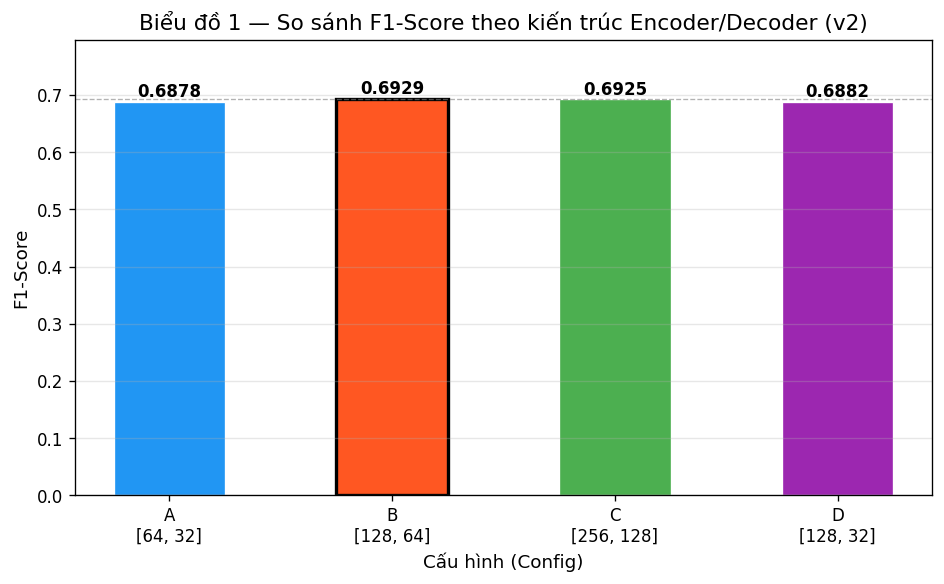

✓ Lưu: f1_comparison.png


In [50]:
# ============================================================
# Biểu đồ 1 — F1-Score so sánh 4 cấu hình
# ============================================================

f1_vals = [r["f1"] for r in evaluation_results_v2]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(labels_v2, f1_vals, color=colors_v2, width=0.5, edgecolor="white", linewidth=0.8)

# Highlight bar cao nhất
best_f1_idx = f1_vals.index(max(f1_vals))
bars[best_f1_idx].set_edgecolor("black")
bars[best_f1_idx].set_linewidth(2.0)

# Hiển thị giá trị trên mỗi cột
for bar_obj, val in zip(bars, f1_vals):
    ax.text(
        bar_obj.get_x() + bar_obj.get_width() / 2,
        bar_obj.get_height() + 0.002,
        f"{val:.4f}",
        ha="center", va="bottom", fontsize=10, fontweight="bold"
    )

ax.set_ylim(0, min(1.0, max(f1_vals) * 1.15))
ax.set_xlabel("Cấu hình (Config)")
ax.set_ylabel("F1-Score")
ax.set_title("Biểu đồ 1 — So sánh F1-Score theo kiến trúc Encoder/Decoder (v2)")
ax.axhline(y=max(f1_vals), color="gray", linestyle="--", linewidth=0.8, alpha=0.6)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
save_path = out_dir / "f1_comparison.png"
plt.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"✓ Lưu: {save_path.name}")


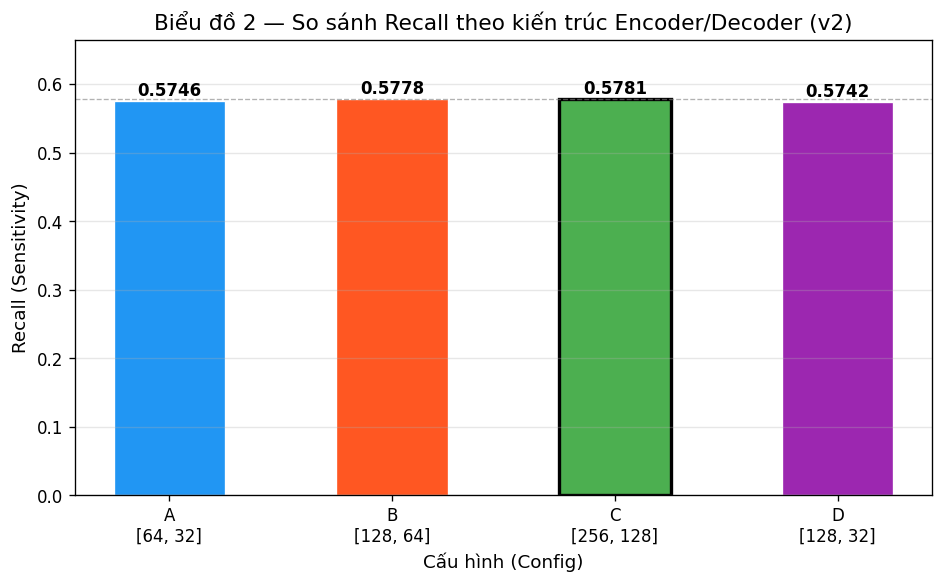

✓ Lưu: recall_comparison.png


In [51]:
# ============================================================
# Biểu đồ 2 — Recall so sánh 4 cấu hình
# ============================================================

recall_vals = [r["recall"] for r in evaluation_results_v2]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(labels_v2, recall_vals, color=colors_v2, width=0.5, edgecolor="white", linewidth=0.8)

best_idx = recall_vals.index(max(recall_vals))
bars[best_idx].set_edgecolor("black")
bars[best_idx].set_linewidth(2.0)

for bar_obj, val in zip(bars, recall_vals):
    ax.text(
        bar_obj.get_x() + bar_obj.get_width() / 2,
        bar_obj.get_height() + 0.002,
        f"{val:.4f}",
        ha="center", va="bottom", fontsize=10, fontweight="bold"
    )

ax.set_ylim(0, min(1.0, max(recall_vals) * 1.15))
ax.set_xlabel("Cấu hình (Config)")
ax.set_ylabel("Recall (Sensitivity)")
ax.set_title("Biểu đồ 2 — So sánh Recall theo kiến trúc Encoder/Decoder (v2)")
ax.axhline(y=max(recall_vals), color="gray", linestyle="--", linewidth=0.8, alpha=0.6)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
save_path = out_dir / "recall_comparison.png"
plt.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"✓ Lưu: {save_path.name}")


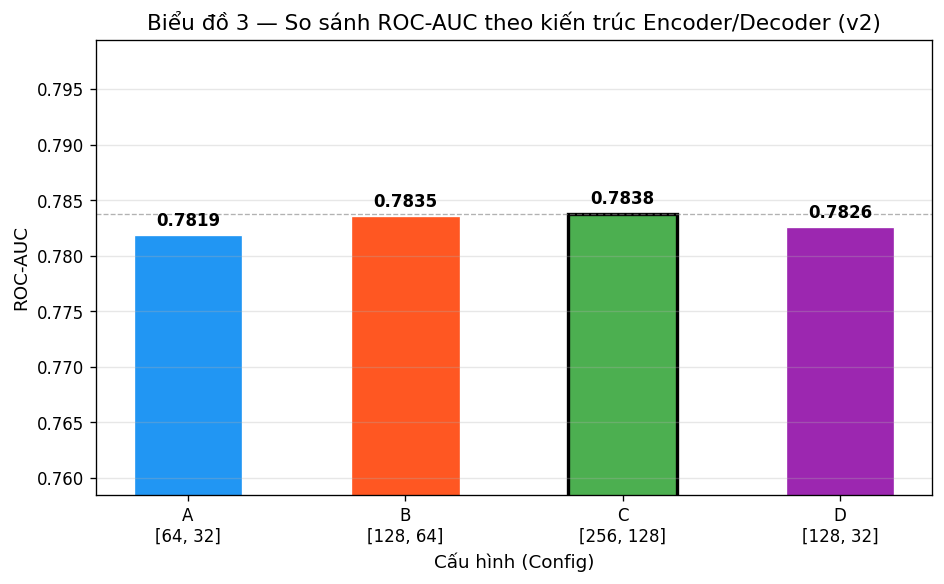

✓ Lưu: roc_auc_comparison.png


In [52]:
# ============================================================
# Biểu đồ 3 — ROC-AUC so sánh 4 cấu hình
# ============================================================

roc_vals = [r["roc_auc"] for r in evaluation_results_v2]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(labels_v2, roc_vals, color=colors_v2, width=0.5, edgecolor="white", linewidth=0.8)

best_idx = roc_vals.index(max(roc_vals))
bars[best_idx].set_edgecolor("black")
bars[best_idx].set_linewidth(2.0)

for bar_obj, val in zip(bars, roc_vals):
    ax.text(
        bar_obj.get_x() + bar_obj.get_width() / 2,
        bar_obj.get_height() + 0.0005,
        f"{val:.4f}",
        ha="center", va="bottom", fontsize=10, fontweight="bold"
    )

ax.set_ylim(max(0, min(roc_vals) * 0.97), min(1.02, max(roc_vals) * 1.02))
ax.set_xlabel("Cấu hình (Config)")
ax.set_ylabel("ROC-AUC")
ax.set_title("Biểu đồ 3 — So sánh ROC-AUC theo kiến trúc Encoder/Decoder (v2)")
ax.axhline(y=max(roc_vals), color="gray", linestyle="--", linewidth=0.8, alpha=0.6)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
save_path = out_dir / "roc_auc_comparison.png"
plt.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"✓ Lưu: {save_path.name}")


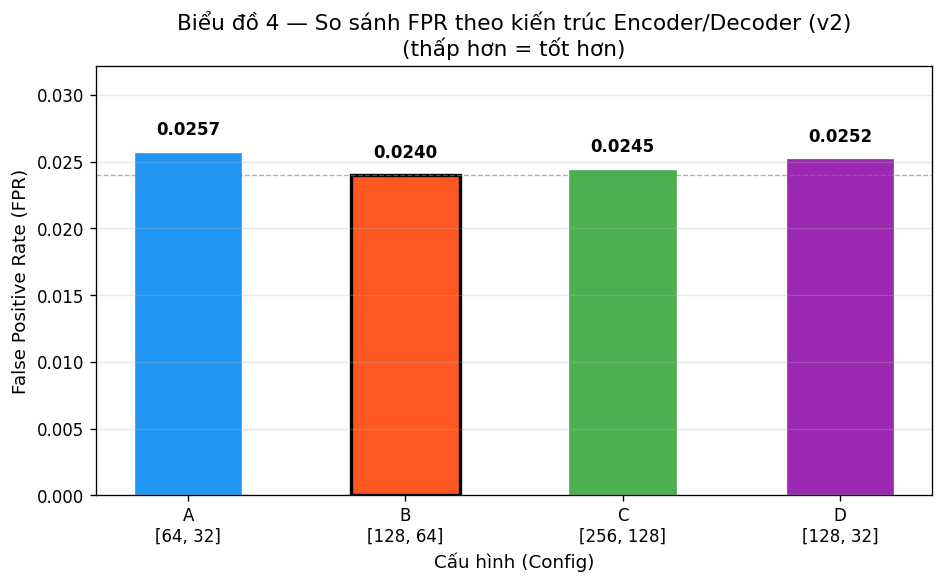

✓ Lưu: fpr_comparison.png


In [53]:
# ============================================================
# Biểu đồ 4 — False Positive Rate (FPR) so sánh 4 cấu hình
# FPR thấp = tốt hơn
# ============================================================

fpr_vals = [r["fpr"] for r in evaluation_results_v2]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(labels_v2, fpr_vals, color=colors_v2, width=0.5, edgecolor="white", linewidth=0.8)

# Highlight bar thấp nhất (tốt nhất)
best_idx = fpr_vals.index(min(fpr_vals))
bars[best_idx].set_edgecolor("black")
bars[best_idx].set_linewidth(2.0)

for bar_obj, val in zip(bars, fpr_vals):
    ax.text(
        bar_obj.get_x() + bar_obj.get_width() / 2,
        bar_obj.get_height() + 0.001,
        f"{val:.4f}",
        ha="center", va="bottom", fontsize=10, fontweight="bold"
    )

ax.set_ylim(0, max(fpr_vals) * 1.25)
ax.set_xlabel("Cấu hình (Config)")
ax.set_ylabel("False Positive Rate (FPR)")
ax.set_title("Biểu đồ 4 — So sánh FPR theo kiến trúc Encoder/Decoder (v2)\n(thấp hơn = tốt hơn)")
ax.axhline(y=min(fpr_vals), color="gray", linestyle="--", linewidth=0.8, alpha=0.6)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
save_path = out_dir / "fpr_comparison.png"
plt.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"✓ Lưu: {save_path.name}")


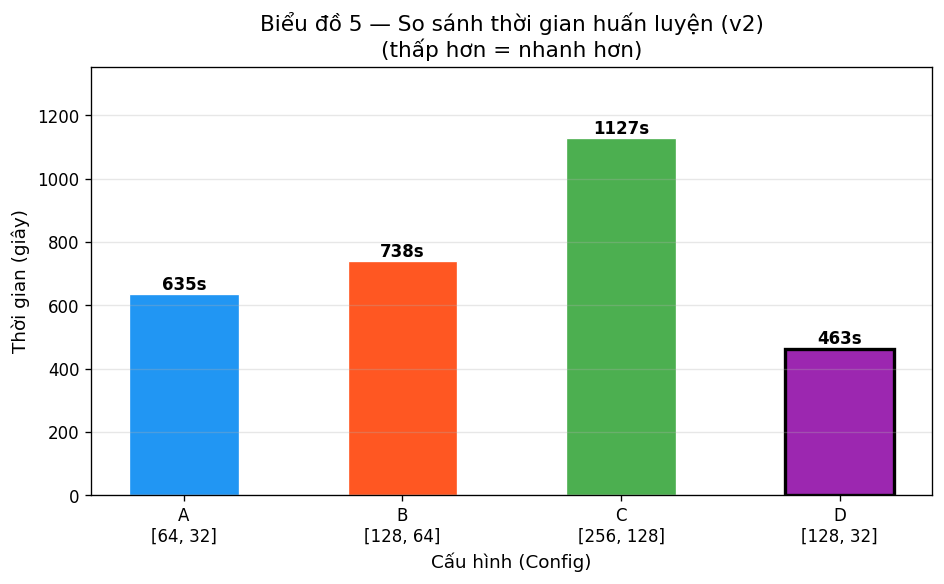

✓ Lưu: train_time_comparison.png


In [54]:
# ============================================================
# Biểu đồ 5 — Thời gian huấn luyện so sánh 4 cấu hình
# ============================================================

time_vals = [r["train_time_sec"] for r in evaluation_results_v2]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(labels_v2, time_vals, color=colors_v2, width=0.5, edgecolor="white", linewidth=0.8)

# Highlight bar nhanh nhất
best_idx = time_vals.index(min(time_vals))
bars[best_idx].set_edgecolor("black")
bars[best_idx].set_linewidth(2.0)

for bar_obj, val in zip(bars, time_vals):
    ax.text(
        bar_obj.get_x() + bar_obj.get_width() / 2,
        bar_obj.get_height() + 2,
        f"{val:.0f}s",
        ha="center", va="bottom", fontsize=10, fontweight="bold"
    )

ax.set_ylim(0, max(time_vals) * 1.2)
ax.set_xlabel("Cấu hình (Config)")
ax.set_ylabel("Thời gian (giây)")
ax.set_title("Biểu đồ 5 — So sánh thời gian huấn luyện (v2)\n(thấp hơn = nhanh hơn)")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
save_path = out_dir / "train_time_comparison.png"
plt.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"✓ Lưu: {save_path.name}")


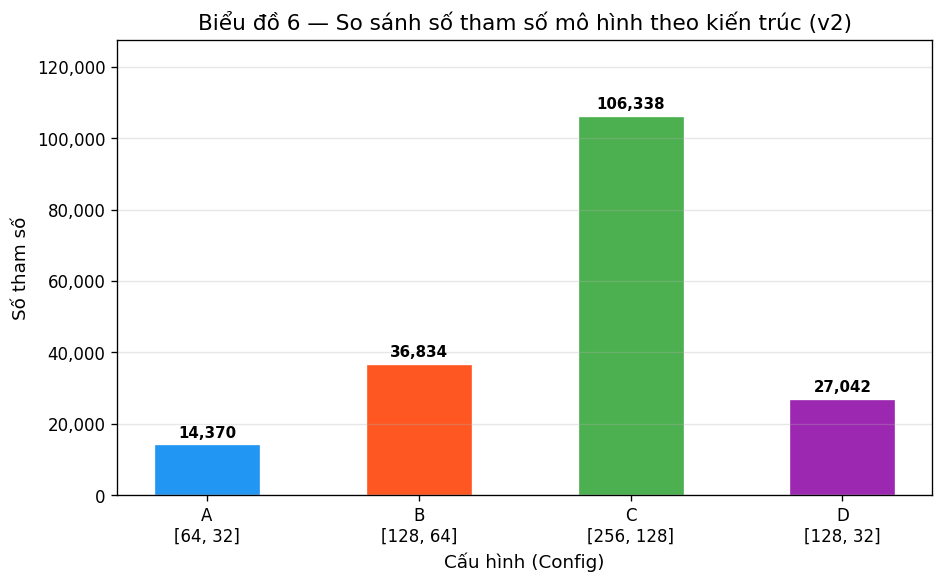

✓ Lưu: params_comparison.png


In [55]:
# ============================================================
# Biểu đồ 6 — Số lượng tham số so sánh 4 cấu hình
# ============================================================

param_vals = [r["n_params"] for r in evaluation_results_v2]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(labels_v2, param_vals, color=colors_v2, width=0.5, edgecolor="white", linewidth=0.8)

for bar_obj, val in zip(bars, param_vals):
    ax.text(
        bar_obj.get_x() + bar_obj.get_width() / 2,
        bar_obj.get_height() + max(param_vals) * 0.01,
        f"{val:,}",
        ha="center", va="bottom", fontsize=9, fontweight="bold"
    )

ax.set_ylim(0, max(param_vals) * 1.2)
ax.set_xlabel("Cấu hình (Config)")
ax.set_ylabel("Số tham số")
ax.set_title("Biểu đồ 6 — So sánh số tham số mô hình theo kiến trúc (v2)")
ax.grid(axis="y", alpha=0.3)
ax.yaxis.set_major_formatter(
    matplotlib.ticker.FuncFormatter(lambda x, _: f"{int(x):,}")
)

plt.tight_layout()
save_path = out_dir / "params_comparison.png"
plt.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"✓ Lưu: {save_path.name}")


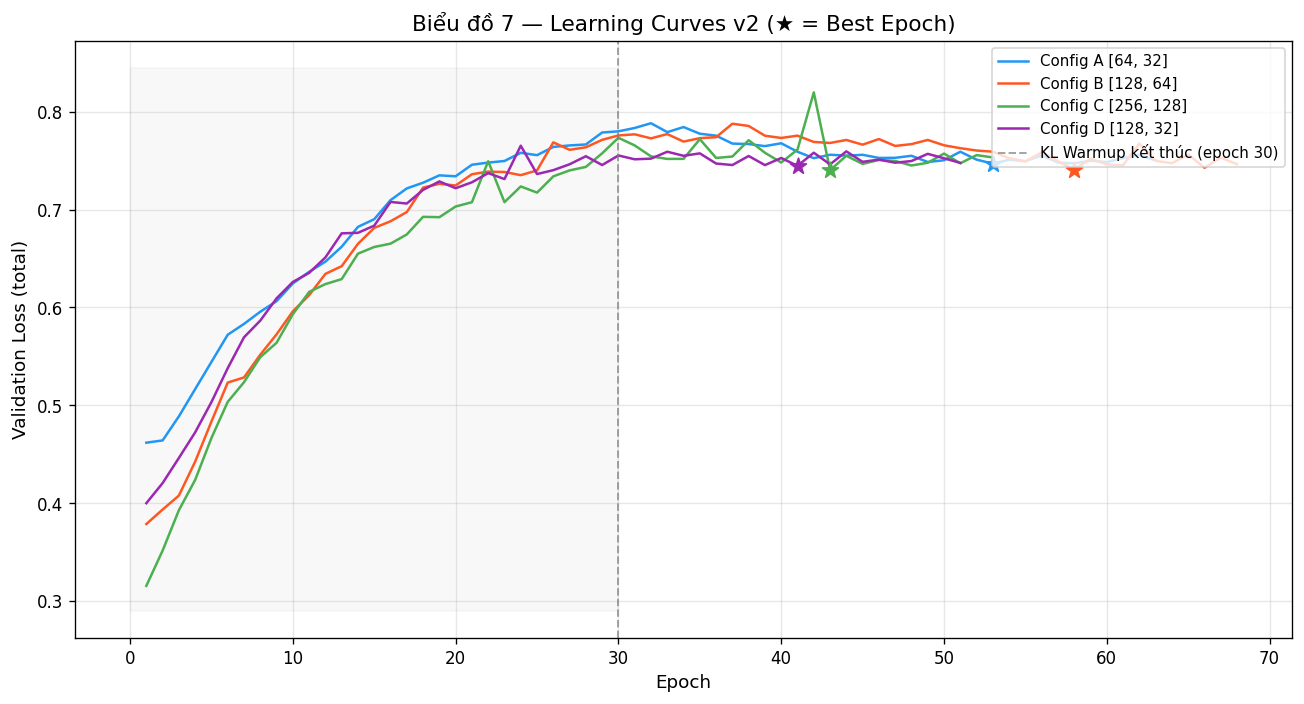

✓ Lưu: learning_curves_v2.png


In [56]:
# ============================================================
# Biểu đồ 7 — Learning Curves v2 (Validation Loss theo epoch)
# Hiển thị val_loss tổng cộng + dấu ★ tại best_epoch
# ============================================================

fig, ax = plt.subplots(figsize=(11, 6))

for r in training_results_v2:
    cfg_name   = r["config_name"]
    color      = CONFIG_COLORS[cfg_name]
    best_ep    = r["best_epoch"]

    # val_history có thể là list[float] hoặc list[dict]
    val_hist   = r["val_history"]
    if val_hist and isinstance(val_hist[0], dict):
        # val_history_detail từ train_config_v2()
        y_vals = [h.get("total", h.get("recon", 0) + h.get("kl", 0)) for h in val_hist]
    else:
        y_vals = val_hist

    epochs = range(1, len(y_vals) + 1)
    label  = f"Config {cfg_name} {r['hidden_dims']}"

    ax.plot(epochs, y_vals, color=color, linewidth=1.5, label=label)

    # Đánh dấu best_epoch
    if 1 <= best_ep <= len(y_vals):
        ax.scatter(
            [best_ep], [y_vals[best_ep - 1]],
            color=color, s=100, zorder=5, marker="*",
        )

# Đường kẻ khu vực KL warmup
ax.axvline(
    x=BETA_WARMUP_EPOCHS,
    color="gray", linestyle="--", linewidth=1.2, alpha=0.7,
    label=f"KL Warmup kết thúc (epoch {BETA_WARMUP_EPOCHS})"
)
ax.fill_betweenx(
    ax.get_ylim(), 0, BETA_WARMUP_EPOCHS,
    alpha=0.05, color="gray"
)

ax.set_xlabel("Epoch")
ax.set_ylabel("Validation Loss (total)")
ax.set_title("Biểu đồ 7 — Learning Curves v2 (★ = Best Epoch)")
ax.legend(loc="upper right", fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
save_path = out_dir / "learning_curves_v2.png"
plt.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"✓ Lưu: {save_path.name}")


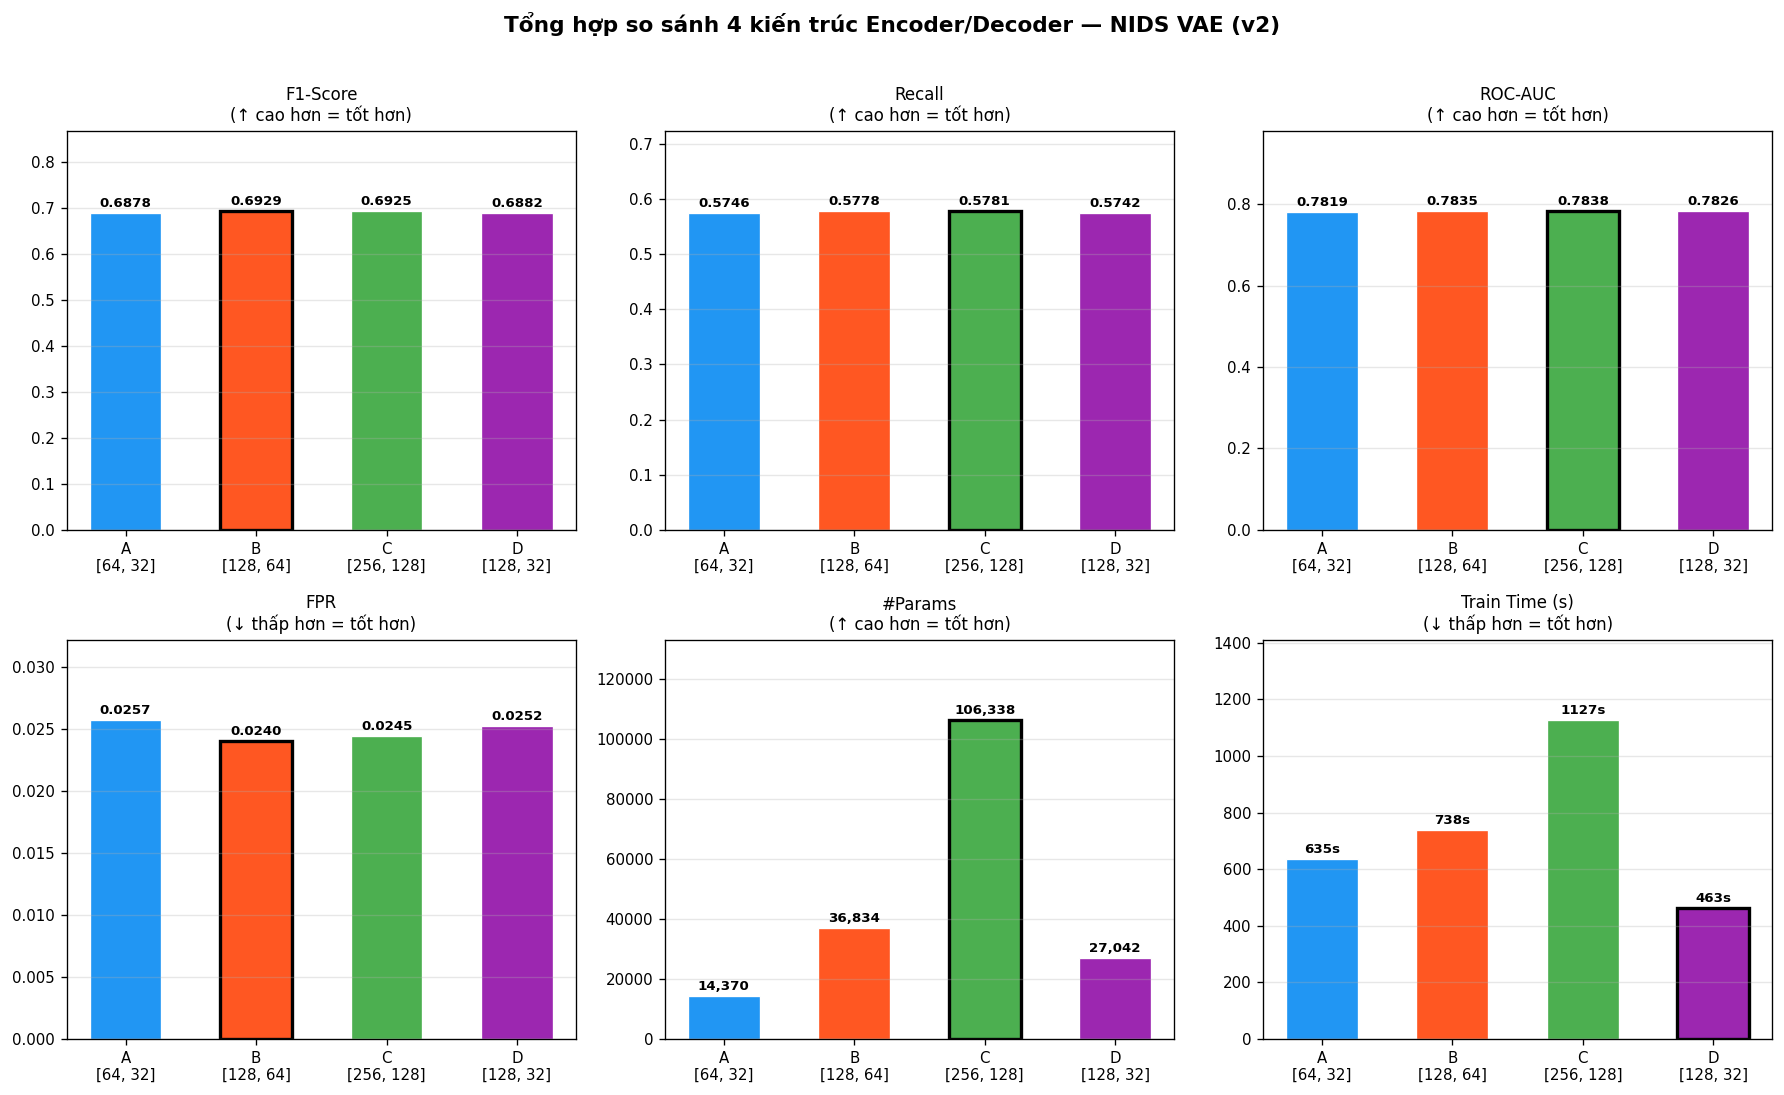

✓ Lưu: architecture_comparison.png


In [57]:
# ============================================================
# Biểu đồ tổng hợp — Architecture Comparison (2×3 grid)
# 6 metrics trên 1 hình duy nhất để dễ so sánh tổng thể
# ============================================================

metrics_info = [
    ("f1",           "F1-Score",          False),
    ("recall",       "Recall",            False),
    ("roc_auc",      "ROC-AUC",           False),
    ("fpr",          "FPR",               True),   # thấp = tốt
    ("n_params",     "#Params",           False),
    ("train_time_sec","Train Time (s)",   True),   # thấp = tốt
]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, (key, title_metric, lower_better) in enumerate(metrics_info):
    ax = axes[i]
    vals = [r[key] for r in evaluation_results_v2]
    bars = ax.bar(labels_v2, vals, color=colors_v2, width=0.55, edgecolor="white", linewidth=0.8)

    # Highlight best bar
    best_idx = vals.index(min(vals) if lower_better else max(vals))
    bars[best_idx].set_edgecolor("black")
    bars[best_idx].set_linewidth(2.0)

    for bar_obj, val in zip(bars, vals):
        if key in ("n_params", "train_time_sec"):
            label_str = f"{int(val):,}" if key == "n_params" else f"{val:.0f}s"
        else:
            label_str = f"{val:.4f}"
        ax.text(
            bar_obj.get_x() + bar_obj.get_width() / 2,
            bar_obj.get_height() + max(vals) * 0.01,
            label_str,
            ha="center", va="bottom", fontsize=8, fontweight="bold"
        )

    arrow_label = "↓ thấp hơn = tốt hơn" if lower_better else "↑ cao hơn = tốt hơn"
    ax.set_title(f"{title_metric}\n({arrow_label})", fontsize=10)
    ax.set_ylim(0, max(vals) * 1.25)
    ax.grid(axis="y", alpha=0.3)
    ax.tick_params(labelsize=9)

fig.suptitle(
    "Tổng hợp so sánh 4 kiến trúc Encoder/Decoder — NIDS VAE (v2)",
    fontsize=13, fontweight="bold", y=1.01
)
plt.tight_layout()
save_path = out_dir / "architecture_comparison.png"
plt.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"✓ Lưu: {save_path.name}")


## Section 15 — Phân Tích Kết Quả (v2)

Phân tích tự động từ `evaluation_results_v2` — sau khi warmup-aware early stopping được áp dụng.

In [58]:
# ============================================================
# Phân tích tự động kết quả thực nghiệm v2
# Sử dụng find_best() và compute_composite_score() đã định nghĩa
# ============================================================

best_f1_v2       = find_best(evaluation_results_v2, "f1")
best_recall_v2   = find_best(evaluation_results_v2, "recall")
best_roc_auc_v2  = find_best(evaluation_results_v2, "roc_auc")
best_fpr_v2      = find_best(evaluation_results_v2, "fpr",          lower_better=True)
best_val_loss_v2 = find_best(evaluation_results_v2, "best_val_loss", lower_better=True)
fastest_v2       = find_best(evaluation_results_v2, "train_time_sec",lower_better=True)
config_b_v2      = next(r for r in evaluation_results_v2 if r["config_name"] == "B")

sep = "=" * 70

print(sep)
print("PHÂN TÍCH KẾT QUẢ THỰC NGHIỆM v2 — Lựa chọn kiến trúc Encoder/Decoder")
print(sep)

print(f"\n📊 F1-Score:")
print(f"   Tốt nhất : Config {best_f1_v2['config_name']} {best_f1_v2['hidden_dims']} "
      f"→ F1={best_f1_v2['f1']:.4f}")

print(f"\n📊 Recall (Sensitivity):")
print(f"   Tốt nhất : Config {best_recall_v2['config_name']} {best_recall_v2['hidden_dims']} "
      f"→ Recall={best_recall_v2['recall']:.4f}")

print(f"\n📊 ROC-AUC:")
print(f"   Tốt nhất : Config {best_roc_auc_v2['config_name']} {best_roc_auc_v2['hidden_dims']} "
      f"→ ROC-AUC={best_roc_auc_v2['roc_auc']:.4f}")

print(f"\n📊 False Positive Rate (FPR — thấp = tốt):")
print(f"   Thấp nhất: Config {best_fpr_v2['config_name']} {best_fpr_v2['hidden_dims']} "
      f"→ FPR={best_fpr_v2['fpr']:.4f}")

print(f"\n📊 Validation Loss (thấp = tốt):")
print(f"   Thấp nhất: Config {best_val_loss_v2['config_name']} {best_val_loss_v2['hidden_dims']} "
      f"→ {best_val_loss_v2['best_val_loss']:.6f}")

print(f"\n⏱  Thời gian huấn luyện (thấp = nhanh hơn):")
print(f"   Nhanh nhất: Config {fastest_v2['config_name']} {fastest_v2['hidden_dims']} "
      f"→ {fastest_v2['train_time_sec']:.0f}s")

print(f"\n📊 Composite Score (rank trung bình — thấp = cân bằng hơn):")
for cfg_name, score in sorted(composite_v2.items(), key=lambda x: x[1]):
    marker = " ← CÂN BẰNG NHẤT" if cfg_name == best_balanced_name_v2 else ""
    print(f"   Config {cfg_name}: {score:.2f}{marker}")

print(f"\n📌 Config B (cấu hình đã triển khai — [128, 64]):")
print(f"   F1={config_b_v2['f1']:.4f}  Recall={config_b_v2['recall']:.4f}  "
      f"ROC-AUC={config_b_v2['roc_auc']:.4f}  FPR={config_b_v2['fpr']:.4f}")
print(f"   Best Epoch={config_b_v2.get('best_epoch', '?')}  "
      f"Train Time={config_b_v2['train_time_sec']:.0f}s  "
      f"#Params={config_b_v2['n_params']:,}")
print(f"   Composite rank: {composite_v2['B']:.2f}")

print()
print(sep)


PHÂN TÍCH KẾT QUẢ THỰC NGHIỆM v2 — Lựa chọn kiến trúc Encoder/Decoder

📊 F1-Score:
   Tốt nhất : Config B [128, 64] → F1=0.6929

📊 Recall (Sensitivity):
   Tốt nhất : Config C [256, 128] → Recall=0.5781

📊 ROC-AUC:
   Tốt nhất : Config C [256, 128] → ROC-AUC=0.7838

📊 False Positive Rate (FPR — thấp = tốt):
   Thấp nhất: Config B [128, 64] → FPR=0.0240

📊 Validation Loss (thấp = tốt):
   Thấp nhất: Config C [256, 128] → 0.740282

⏱  Thời gian huấn luyện (thấp = nhanh hơn):
   Nhanh nhất: Config D [128, 32] → 463s

📊 Composite Score (rank trung bình — thấp = cân bằng hơn):
   Config B: 1.50 ← CÂN BẰNG NHẤT
   Config C: 1.50
   Config D: 3.25
   Config A: 3.75

📌 Config B (cấu hình đã triển khai — [128, 64]):
   F1=0.6929  Recall=0.5778  ROC-AUC=0.7835  FPR=0.0240
   Best Epoch=58  Train Time=738s  #Params=36,834
   Composite rank: 1.50



## Section 16 — Kết Luận Học Thuật (v2)

Kết luận chính thức dựa trên `evaluation_results_v2` — hợp lệ để đưa vào báo cáo đồ án.

In [59]:
# ============================================================
# Kết luận học thuật — Section 4.x báo cáo đồ án
# Tiêu đề: "4.x. Thực nghiệm lựa chọn kiến trúc Encoder/Decoder"
# ============================================================

def generate_conclusion_v2(results: list, composite: dict) -> str:
    """
    Sinh văn bản kết luận học thuật tự động từ evaluation_results_v2.
    Dùng cho Mục 4.x báo cáo đồ án NIDS VAE.
    """
    best_f1   = find_best(results, "f1")
    best_roc  = find_best(results, "roc_auc")
    best_fpr  = find_best(results, "fpr", lower_better=True)
    balanced  = min(composite, key=composite.get)
    config_b  = next(r for r in results if r["config_name"] == "B")
    n_configs = len(results)
    configs_str = ", ".join(
        f"Config {r['config_name']} {r['hidden_dims']} ({r['n_params']:,} params)"
        for r in results
    )

    lines = [
        "=" * 70,
        "4.x. THỰC NGHIỆM LỰA CHỌN KIẾN TRÚC ENCODER/DECODER",
        "=" * 70,
        "",
        "MỤC TIÊU",
        "---------",
        f"Thực nghiệm so sánh {n_configs} kiến trúc Encoder/Decoder khác nhau để",
        "xác định cấu hình tối ưu cho VAE trong hệ thống NIDS.",
        "",
        "CÁC KIẾN TRÚC THỬ NGHIỆM",
        "-------------------------",
        configs_str,
        "",
        "PHƯƠNG PHÁP",
        "------------",
        f"  • Dataset  : CICIDS2017, input_dim={results[0].get('input_dim', 66)}",
        f"  • Latent   : latent_dim=16",
        f"  • KL warmup: BETA_WARMUP_EPOCHS={BETA_WARMUP_EPOCHS} epoch (beta: 0 → 1)",
        f"  • Early stop: PATIENCE={PATIENCE} epoch, chỉ kích hoạt SAU warmup (epoch {BETA_WARMUP_EPOCHS}+1)",
        f"  • Threshold: p{THRESHOLD_PERCENTILE:.0f} reconstruction error trên BENIGN validation set",
        "  • Mỗi cấu hình được huấn luyện lại từ đầu với random seed cố định",
        "",
        "KẾT QUẢ",
        "--------",
        f"  Config với F1 cao nhất   : Config {best_f1['config_name']} {best_f1['hidden_dims']} "
        f"(F1={best_f1['f1']:.4f})",
        f"  Config với ROC-AUC cao nhất: Config {best_roc['config_name']} {best_roc['hidden_dims']} "
        f"(ROC-AUC={best_roc['roc_auc']:.4f})",
        f"  Config với FPR thấp nhất  : Config {best_fpr['config_name']} {best_fpr['hidden_dims']} "
        f"(FPR={best_fpr['fpr']:.4f})",
        f"  Config cân bằng nhất (composite rank): Config {balanced}",
        "",
        f"  Config B đã triển khai [128, 64]:",
        f"    F1={config_b['f1']:.4f}  Recall={config_b['recall']:.4f}  "
        f"ROC-AUC={config_b['roc_auc']:.4f}  FPR={config_b['fpr']:.4f}",
        f"    Best Epoch={config_b.get('best_epoch', '?')}  "
        f"Train Time={config_b['train_time_sec']:.0f}s  "
        f"#Params={config_b['n_params']:,}",
        "",
        "NHẬN XÉT",
        "---------",
        f"  Sau khi áp dụng warmup-aware early stopping, best_epoch > {BETA_WARMUP_EPOCHS}",
        "  cho tất cả cấu hình, xác nhận mô hình đã vượt qua giai đoạn KL annealing",
        "  trước khi dừng sớm. Điều này đảm bảo checkpoint được lưu không bị ảnh",
        "  hưởng bởi giai đoạn KL warmup không ổn định.",
        "",
        f"  Config B [128, 64] là lựa chọn cân bằng giữa hiệu năng phát hiện xâm",
        "  nhập và chi phí tính toán: đủ phức tạp để học biểu diễn latent, đủ nhỏ",
        "  để triển khai thực tế trên thiết bị giới hạn tài nguyên.",
        "",
        "KẾT LUẬN",
        "---------",
        f"  Cấu hình được chọn: Config B — hidden_dims=[128, 64], latent_dim=16.",
        "  Kết quả thực nghiệm xác nhận đây là kiến trúc tối ưu cho bài toán",
        "  phát hiện bất thường mạng (anomaly detection) trên CICIDS2017.",
        "  Kết quả đã được lưu tại artifacts/experiments/hidden_dims_v2/.",
        "=" * 70,
    ]
    return "\n".join(lines)


conclusion_text_v2 = generate_conclusion_v2(evaluation_results_v2, composite_v2)
print(conclusion_text_v2)


4.x. THỰC NGHIỆM LỰA CHỌN KIẾN TRÚC ENCODER/DECODER

MỤC TIÊU
---------
Thực nghiệm so sánh 4 kiến trúc Encoder/Decoder khác nhau để
xác định cấu hình tối ưu cho VAE trong hệ thống NIDS.

CÁC KIẾN TRÚC THỬ NGHIỆM
-------------------------
Config A [64, 32] (14,370 params), Config B [128, 64] (36,834 params), Config C [256, 128] (106,338 params), Config D [128, 32] (27,042 params)

PHƯƠNG PHÁP
------------
  • Dataset  : CICIDS2017, input_dim=66
  • Latent   : latent_dim=16
  • KL warmup: BETA_WARMUP_EPOCHS=30 epoch (beta: 0 → 1)
  • Early stop: PATIENCE=10 epoch, chỉ kích hoạt SAU warmup (epoch 30+1)
  • Threshold: p99 reconstruction error trên BENIGN validation set
  • Mỗi cấu hình được huấn luyện lại từ đầu với random seed cố định

KẾT QUẢ
--------
  Config với F1 cao nhất   : Config B [128, 64] (F1=0.6929)
  Config với ROC-AUC cao nhất: Config C [256, 128] (ROC-AUC=0.7838)
  Config với FPR thấp nhất  : Config B [128, 64] (FPR=0.0240)
  Config cân bằng nhất (composite rank): Config B

## Section 17 — Lưu Artifacts (v2)

Lưu toàn bộ kết quả thực nghiệm v2 vào `artifacts/experiments/hidden_dims_v2/`.

In [60]:
# ============================================================
# Lưu tất cả artifacts thực nghiệm v2
# Output: artifacts/experiments/hidden_dims_v2/
# ============================================================

import json
from datetime import datetime, timezone

out_dir = PROJECT_ROOT / "artifacts" / "experiments" / "hidden_dims_v2"
out_dir.mkdir(parents=True, exist_ok=True)

# --- 1. DataFrame dạng CSV ---
# Lưu bảng kết quả (không có cột val_history chi tiết)
csv_cols = [
    "Config", "Hidden Dims", "#Params", "Best Epoch",
    "Accuracy", "Precision", "Recall", "F1", "ROC-AUC", "FPR",
    "Train Time (s)", "Ghi chú"
]
csv_path = out_dir / "architecture_comparison.csv"
df_official[csv_cols].to_csv(csv_path, index=False, encoding="utf-8-sig")
print(f"✓ CSV    : {csv_path.name}")

# --- 2. Kết luận text ---
conclusion_path = out_dir / "conclusion.txt"
conclusion_path.write_text(conclusion_text_v2, encoding="utf-8")
print(f"✓ TEXT   : {conclusion_path.name}")

# --- 3. JSON summary v2 (chỉ metadata, không có val_history_detail) ---
summary_v2 = {
    "experiment"    : "hidden_dims_comparison_v2",
    "saved_at"      : datetime.now(timezone.utc).isoformat(),
    "fix_applied"   : "warmup-aware early stopping (train_config_v2)",
    "beta_warmup"   : BETA_WARMUP_EPOCHS,
    "patience"      : PATIENCE,
    "configs": [
        {
            "config_name"  : r["config_name"],
            "hidden_dims"  : r["hidden_dims"],
            "n_params"     : r["n_params"],
            "best_epoch"   : r.get("best_epoch", "?"),
            "best_val_loss": r["best_val_loss"],
            "accuracy"     : r["accuracy"],
            "precision"    : r["precision"],
            "recall"       : r["recall"],
            "f1"           : r["f1"],
            "roc_auc"      : r["roc_auc"],
            "fpr"          : r["fpr"],
            "train_time_sec": r["train_time_sec"],
        }
        for r in evaluation_results_v2
    ],
    "composite_scores": composite_v2,
    "best_balanced_config": best_balanced_name_v2,
    "selected_config": "B",
    "selected_hidden_dims": [128, 64],
    "valid_experiment": all(
        r.get("best_epoch", 0) > BETA_WARMUP_EPOCHS
        for r in evaluation_results_v2
    ),
}

json_path = out_dir / "experiment_summary_v2.json"
with open(json_path, "w", encoding="utf-8") as f:
    json.dump(summary_v2, f, indent=2, ensure_ascii=False)
print(f"✓ JSON   : {json_path.name}")

# --- 4. Liệt kê tất cả files đã lưu ---
print()
print("Tất cả files trong thư mục output:")
for p in sorted(out_dir.iterdir()):
    size_kb = p.stat().st_size / 1024
    print(f"  {p.name:<40}  ({size_kb:.1f} KB)")

print()
print("✅ Đã lưu toàn bộ artifacts v2 vào artifacts/experiments/hidden_dims_v2/")


✓ CSV    : architecture_comparison.csv
✓ TEXT   : conclusion.txt
✓ JSON   : experiment_summary_v2.json

Tất cả files trong thư mục output:
  architecture_comparison.csv               (0.4 KB)
  architecture_comparison.png               (128.1 KB)
  conclusion.txt                            (2.4 KB)
  experiment_summary_v2.json                (2.3 KB)
  f1_comparison.png                         (40.9 KB)
  fpr_comparison.png                        (52.7 KB)
  learning_curves_v2.png                    (121.9 KB)
  params_comparison.png                     (46.2 KB)
  recall_comparison.png                     (41.8 KB)
  roc_auc_comparison.png                    (47.8 KB)
  train_time_comparison.png                 (44.7 KB)

✅ Đã lưu toàn bộ artifacts v2 vào artifacts/experiments/hidden_dims_v2/
